# Trabajo Práctico Integrador — Análisis de Datos

**Carrera de Especialización en Inteligencia Artificial — FIUBA — 3B 2026**

| | |
|---|---|
| **Grupo** | `[COMPLETAR]` |
| **Integrantes** | `[COMPLETAR]` |
| **Dataset** | High Volume For-Hire Vehicle (HVFHV) — viajes de Uber y Lyft en Nueva York |
| **Fuente** | NYC Taxi & Limousine Commission (datos públicos) |
| **Período** | Agosto 2025 |
| **Repositorio** | https://github.com/SilvertK164/ceia-analisis-datos-tp-hvfhs |

---

## De qué se trata este trabajo

El dataset registra **todos** los viajes de Uber y Lyft realizados en la ciudad de Nueva
York. Cada fila es un viaje: cuándo se pidió, cuándo subió el pasajero, cuánto duró, cuánto
costó y cuánto cobró el conductor.

Sobre esos datos vamos a:

1. Explorar y entender el dataset (§1 a §6)
2. Detectar sus problemas de calidad: faltantes, errores y outliers (§7 y §8)
3. Plantear un problema de Machine Learning supervisado (§9)
4. Preparar los datos para ese problema (§10 a §16)
5. Reducir la dimensionalidad con selección de features y PCA (§17 y §18)
6. **Dejar los datasets de train y test listos para entrenar** (§19)
7. Sacar conclusiones (§20)

El recorrido de §10 a §19 sigue el **flujo de preparación de datos** de la cátedra
(Clase 5 slide 37, completado en Clase 7 slides 5 y 26), y toma como modelo la notebook
`recursos/taller_clasificacion.ipynb`.

> **El entrenamiento del modelo no forma parte de la consigna.** Lo que se pide es
> *plantear* el problema y *preparar* los datos, no resolverlo.

## Por qué analizamos un solo mes

El año 2025 completo son unos **240 millones de registros** repartidos en 12 archivos.
Trabajar sobre un único mes fue **sugerencia de la cátedra** dada esa magnitud.

Agosto 2025 por sí solo aporta **más de 19 millones de viajes**, de sobra para todo lo que
pide la consigna.

## Índice

| | Sección | Qué contiene |
|---|---|---|
| **Parte 1 — Explorar** | | |
| §1 | Carga del dataset | Cuántas filas, cuántas columnas, qué tipos |
| §2 | Diccionario de variables | Qué significa cada columna |
| §3 | Variables derivadas | Las 6 que creamos y por qué |
| §4 | Descriptiva numérica | Percentiles, asimetría |
| §5 | Descriptiva categórica | Frecuencias, cardinalidad, entropía |
| §6 | Visualizaciones | Qué gráfico corresponde a cada tipo de variable |
| **Parte 2 — Calidad de los datos** | | |
| §7 | Faltantes y su tipo ⭐ | MCAR / MAR / MNAR / estructural |
| §8 | Errores y outliers | La diferencia entre un error y un valor atípico |
| **Parte 3 — El problema** | | |
| §9 | Problema de ML y target | Qué vamos a predecir |
| **Parte 4 — Preparación** | | |
| §10 | Limpieza general | Qué filas y columnas se descartan |
| §11 | Split del dataset ⭐ | Por qué va antes que todo lo demás |
| §12 | Tratamiento de faltantes | |
| §13 | Tratamiento de outliers | |
| §14 | Codificación y discretización | Una técnica distinta para cada tipo |
| §15 | Estandarización | |
| §16 | Balance de clases | Solo sobre entrenamiento |
| **Parte 5 — Reducción de dimensionalidad** | | |
| §17 | Selección de features | Cuáles conservamos y cuáles no |
| §18 | PCA | Extracción de componentes principales |
| **Parte 6 — Cierre** | | |
| §19 | Datasets listos para entrenar | El resultado final del trabajo |
| §20 | Conclusiones | |

⭐ = las dos secciones con los hallazgos más importantes.

## Cómo citamos la teoría

Cada técnica que aplicamos viene precedida por la cita a la clase que la sustenta, con esta
forma: *(Clase 5, slide 5)*. Así queda claro que las decisiones no son arbitrarias.

## §0. Configuración inicial

Primero importamos las bibliotecas y definimos las constantes que vamos a usar en todo el
notebook. Tener las rutas y los parámetros en un solo lugar hace más fácil reproducir el
análisis en otra computadora: solo hay que cambiar `RUTA_DATOS`.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# --- Dónde están los datos ---------------------------------------------------
# Los .parquet NO están en el repositorio (pesan ~480 MB cada uno).
# Se descargan de: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page
RUTA_DATOS = Path(r"c:/Users/LEGION/OneDrive/FIUBA/CEIA/02.- ANALISIS DE DATOS/"
                  r"01.- DATASET/HIGH VOLUME FOR HIRE VEHICLE TRIP RECORDS")
ARCHIVO = RUTA_DATOS / "fhvhv_tripdata_2025-08.parquet"

# --- Dónde guardamos los gráficos --------------------------------------------
CARPETA_FIGURAS = Path("figuras")
CARPETA_FIGURAS.mkdir(exist_ok=True)

# --- Parámetros del análisis -------------------------------------------------
SEMILLA = 42                # para que los resultados sean reproducibles
MUESTRA_GRAFICOS = 200_000  # filas para los gráficos pesados (ver §6)
N_PREPARACION = 1_000_000   # filas para la preparación de datos (ver §11)

# --- Estilo de los gráficos --------------------------------------------------
AZUL = "#2C5F8A"
NARANJA = "#E8792B"
GRIS = "#8C8C8C"

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Bibliotecas cargadas.")
print("pandas:", pd.__version__, "| numpy:", np.__version__)
print("Existe el archivo de datos:", ARCHIVO.exists())

Bibliotecas cargadas.
pandas: 3.0.3 | numpy: 2.4.6
Existe el archivo de datos: True


In [2]:
# Guarda el grafico actual en la carpeta de figuras, listo para las diapositivas
def guardar_figura(nombre):
    ruta = CARPETA_FIGURAS / f"{nombre}.png"
    plt.savefig(ruta, dpi=150, bbox_inches="tight", facecolor="white")
    print(f"   figura guardada: {ruta}")

---

# §1. Carga del dataset y primera mirada

> **Consigna:** *"Cargar el dataset y realizar un análisis exploratorio. Describir las
> características principales del dataset, incluyendo el número de observaciones, número de
> variables y tipos de datos."*

El archivo está en formato **Parquet**, un formato de columnas que ocupa mucho menos que un
CSV y se lee más rápido. Es el formato en el que el NYC TLC publica estos datos.

In [3]:
df = pd.read_parquet(ARCHIVO)

print("=" * 55)
print("TAMAÑO DEL DATASET")
print("=" * 55)
print(f"Observaciones (filas)  : {df.shape[0]:,}")
print(f"Variables (columnas)   : {df.shape[1]}")
print(f"Memoria que ocupa      : {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

TAMAÑO DEL DATASET
Observaciones (filas)  : 19,271,461
Variables (columnas)   : 25
Memoria que ocupa      : 4.11 GB


Más de 19 millones de viajes **en un solo mes**. Para que el dataset ocupe menos memoria,
convertimos las columnas de texto al tipo `category`: en lugar de guardar el texto repetido
millones de veces, pandas guarda la lista de valores distintos y una referencia numérica.

In [4]:
columnas_texto = df.select_dtypes(include=["object", "string"]).columns

for columna in columnas_texto:
    df[columna] = df[columna].astype("category")

print(f"Se convirtieron {len(columnas_texto)} columnas de texto a 'category'.")
print(f"Memoria ahora: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Se convirtieron 8 columnas de texto a 'category'.
Memoria ahora: 2.62 GB


In [5]:
print("TIPOS DE DATOS")
print("=" * 55)
print(df.dtypes.to_string())

TIPOS DE DATOS
hvfhs_license_num             category
dispatching_base_num          category
originating_base_num          category
request_datetime        datetime64[us]
on_scene_datetime       datetime64[us]
pickup_datetime         datetime64[us]
dropoff_datetime        datetime64[us]
PULocationID                     int32
DOLocationID                     int32
trip_miles                     float64
trip_time                        int64
base_passenger_fare            float64
tolls                          float64
bcf                            float64
sales_tax                      float64
congestion_surcharge           float64
airport_fee                    float64
tips                           float64
driver_pay                     float64
shared_request_flag           category
shared_match_flag             category
access_a_ride_flag            category
wav_request_flag              category
wav_match_flag                category
cbd_congestion_fee             float64


In [6]:
# Las primeras filas, para ver como son los datos
df.head()

,hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,...,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,cbd_congestion_fee
0,HV0003,B03404,B03404,2025-08-01 00:07:01,2025-08-01 00:09:06,2025-08-01 00:09:29,2025-08-01 00:22:28,113,158,1.53,...,2.75,0.00,0.00,27.61,N,N,N,N,N,1.50
1,HV0003,B03404,B03404,2025-08-01 00:31:28,2025-08-01 00:35:30,2025-08-01 00:35:50,2025-08-01 00:46:56,144,68,2.06,...,2.75,0.00,0.00,10.39,N,N,N,N,N,1.50
2,HV0003,B03404,B03404,2025-08-01 00:53:16,2025-08-01 00:54:54,2025-08-01 00:56:55,2025-08-01 01:18:05,249,137,2.97,...,2.75,0.00,0.00,18.05,N,N,N,N,N,1.50
3,HV0003,B03404,B03404,2025-08-01 00:52:57,2025-08-01 00:54:47,2025-08-01 00:56:10,2025-08-01 01:02:18,68,158,1.27,...,2.75,0.00,0.00,7.29,N,N,N,N,N,1.50
4,HV0003,B03404,B03404,2025-08-01 00:06:10,2025-08-01 00:09:20,2025-08-01 00:09:44,2025-08-01 00:26:07,174,244,8.27,...,0.00,0.00,0.00,21.05,N,N,N,N,N,0.00


---

# §2. Diccionario de variables y tipos

> **Consigna:** *"Describir las características principales del dataset, incluyendo... los
> tipos de datos."*

Antes de analizar hay que entender qué significa cada columna. Esta información sale del
**diccionario de datos oficial del TLC** (`data_dictionary_trip_records_hvfhs.pdf`), que se
descarga de la misma página que los datos.

| Columna | Qué significa |
|---|---|
| `hvfhs_license_num` | Código de la empresa. `HV0003` = Uber, `HV0005` = Lyft |
| `dispatching_base_num` | Base que despachó el viaje |
| `originating_base_num` | Base que originó el viaje |
| `request_datetime` | Cuándo el pasajero **pidió** el viaje |
| `on_scene_datetime` | Cuándo el conductor **llegó** a buscarlo |
| `pickup_datetime` | Cuándo el pasajero **subió** al vehículo |
| `dropoff_datetime` | Cuándo el pasajero **bajó** |
| `PULocationID` | Zona de origen (1 a 265, según las *taxi zones* de NYC) |
| `DOLocationID` | Zona de destino |
| `trip_miles` | Distancia recorrida, en millas |
| `trip_time` | Duración del viaje, en segundos |
| `base_passenger_fare` | Tarifa base que pagó el pasajero (sin peajes ni impuestos) |
| `tolls` | Peajes |
| `bcf` | *Black Car Fund*, un fondo para conductores |
| `sales_tax` | Impuesto a las ventas |
| `congestion_surcharge` | Recargo por congestión |
| `airport_fee` | Recargo de aeropuerto |
| `tips` | **Propina** |
| `driver_pay` | Lo que cobró el conductor (sin propina) |
| `shared_request_flag` | ¿Pidió viaje compartido? (Y/N) |
| `shared_match_flag` | ¿Se concretó el viaje compartido? (Y/N) |
| `access_a_ride_flag` | ¿Viaje del programa de accesibilidad? (Y/N) |
| `wav_request_flag` | ¿Pidió vehículo accesible para silla de ruedas? (Y/N) |
| `wav_match_flag` | ¿Le asignaron vehículo accesible? (Y/N) |
| `cbd_congestion_fee` | Recargo por circular en el centro de Manhattan |

## Clasificación de las variables

La Clase 1 distingue entre variables **cuantitativas** (las que se pueden contar o medir) y
**categóricas** (cualidades que no se miden), y dentro de las categóricas entre
**nominales** (sin orden) y **ordinales** (con orden). *(Clase 1, slides 37-38)*

La misma clase advierte dos cosas que aplican acá *(Clase 1, slide 38)*:

- **Las variables binarias (Sí/No) son un caso particular de las categóricas nominales.**
  Es el caso de los cinco *flags* `Y`/`N`.
- **Las fechas tienen doble naturaleza**: son numéricas si interesa medir tiempo
  transcurrido, y categóricas si interesa agrupar por día o franja horaria. Vamos a usar
  las dos formas en §3.

Un punto importante: `PULocationID` y `DOLocationID` **parecen numéricas porque son
números, pero no lo son**. La zona 138 no es "más" que la zona 69: el número es solo una
etiqueta. Son **categóricas nominales representadas con números**, tal como advierte la
Clase 1 (*"una variable categórica se puede representar con números, que actúan como un
encoding"*).

In [7]:
# Clasificamos las columnas segun su tipo de dato
variables_fecha = df.select_dtypes(include="datetime").columns.tolist()
variables_texto = df.select_dtypes(include="category").columns.tolist()
variables_numericas = df.select_dtypes(include="number").columns.tolist()

# Correccion: los ID de zona son categoricos aunque esten guardados como numero
ids_de_zona = ["PULocationID", "DOLocationID"]
variables_numericas = [c for c in variables_numericas if c not in ids_de_zona]

print(f"Variables de fecha/hora         ({len(variables_fecha)}):")
print("   ", variables_fecha)
print(f"\nVariables categoricas de texto  ({len(variables_texto)}):")
print("   ", variables_texto)
print(f"\nVariables categoricas numericas ({len(ids_de_zona)}):")
print("   ", ids_de_zona)
print(f"\nVariables numericas de verdad   ({len(variables_numericas)}):")
print("   ", variables_numericas)

Variables de fecha/hora         (4):
    ['request_datetime', 'on_scene_datetime', 'pickup_datetime', 'dropoff_datetime']

Variables categoricas de texto  (8):
    ['hvfhs_license_num', 'dispatching_base_num', 'originating_base_num', 'shared_request_flag', 'shared_match_flag', 'access_a_ride_flag', 'wav_request_flag', 'wav_match_flag']

Variables categoricas numericas (2):
    ['PULocationID', 'DOLocationID']

Variables numericas de verdad   (11):
    ['trip_miles', 'trip_time', 'base_passenger_fare', 'tolls', 'bcf', 'sales_tax', 'congestion_surcharge', 'airport_fee', 'tips', 'driver_pay', 'cbd_congestion_fee']


---

# §3. Variables derivadas

> **Consigna (feature engineering):** *"Crear nuevos features en caso de ser necesario.
> Justificar."*

La Clase 5 da los criterios para crear una variable nueva *(Clase 5, slide 11)*:

> *"Deben ser relevantes para el objetivo. Tienen que capturar relaciones importantes o
> transformaciones de variables guiadas por conocimiento del dominio o análisis. Tienen que
> complementar o superar lo que aportan las variables originales."*

Creamos seis variables. Cada una responde a una pregunta que las columnas originales **no**
contestan directamente:

| Variable nueva | Qué responde | Por qué la creamos |
|---|---|---|
| `empresa` | ¿Uber o Lyft? | El código `HV0003` no se entiende al leerlo |
| `espera_min` | ¿Cuánto esperó el pasajero? | Es `pickup − request`; mide la calidad del servicio |
| `duracion_min` | ¿Cuánto duró el viaje, en minutos? | `trip_time` está en segundos, poco legible |
| `velocidad_mph` | ¿A qué velocidad se movió? | Cruza distancia y tiempo; delata errores y congestión |
| `hora` | ¿A qué hora del día fue? | Permite ver el patrón horario |
| `dia_semana` | ¿Qué día de la semana fue? | Permite ver el patrón semanal |

Las tres últimas usan la **doble naturaleza de las fechas** que menciona la Clase 1: de una
misma columna de fecha extraemos una medida de tiempo (`duracion_min`) y dos agrupadores
categóricos (`hora`, `dia_semana`).

In [8]:
# --- 1. Nombre de la empresa -------------------------------------------------
nombres_empresa = {"HV0003": "Uber", "HV0005": "Lyft"}
df["empresa"] = df["hvfhs_license_num"].astype(str).map(nombres_empresa).astype("category")

# --- 2. Espera del pasajero: desde que pide hasta que sube --------------------
diferencia = df["pickup_datetime"] - df["request_datetime"]
df["espera_min"] = diferencia.dt.total_seconds() / 60

# --- 3. Duracion del viaje en minutos ----------------------------------------
df["duracion_min"] = df["trip_time"] / 60

# --- 4. Velocidad promedio en millas por hora --------------------------------
# Si el viaje duro 0 segundos no se puede calcular: queda como faltante (NaN)
horas_de_viaje = df["trip_time"] / 3600
df["velocidad_mph"] = np.where(horas_de_viaje > 0,
                               df["trip_miles"] / horas_de_viaje,
                               np.nan)

# --- 5 y 6. Hora y dia de la semana del viaje --------------------------------
df["hora"] = df["pickup_datetime"].dt.hour
df["dia_semana"] = df["pickup_datetime"].dt.dayofweek   # 0 = lunes ... 6 = domingo

print("Se crearon 6 variables nuevas.\n")
df[["empresa", "espera_min", "duracion_min", "velocidad_mph", "hora", "dia_semana"]].head()

Se crearon 6 variables nuevas.



,empresa,espera_min,duracion_min,velocidad_mph,hora,dia_semana
0,Uber,2.47,13.00,7.06,0,4
1,Uber,4.37,11.10,11.14,0,4
2,Uber,3.65,21.17,8.42,0,4
3,Uber,3.22,6.15,12.39,0,4
4,Uber,3.57,16.38,30.29,0,4


---

# §4. Estadística descriptiva — variables numéricas

> **Consigna:** *"Identificar patrones generales y distribuciones."*

Miramos las variables numéricas con `describe()`, pidiendo **percentiles extremos** (p1 y
p99) además de los habituales. Los percentiles extremos son los que revelan las colas de la
distribución, que es donde suelen esconderse los errores y los outliers.

In [9]:
columnas_a_describir = [
    "trip_miles", "duracion_min", "espera_min", "velocidad_mph",
    "base_passenger_fare", "driver_pay", "tips", "tolls",
]

resumen = df[columnas_a_describir].describe(
    percentiles=[0.01, 0.25, 0.5, 0.75, 0.95, 0.99]
).T

# Agregamos asimetria y curtosis, como en utils/plotting.py de la catedra
resumen["asimetria"] = df[columnas_a_describir].skew()
resumen["curtosis"] = df[columnas_a_describir].kurt()

resumen[["count", "mean", "std", "min", "1%", "50%", "99%", "max", "asimetria", "curtosis"]]

,count,mean,std,min,1%,50%,99%,max,asimetria,curtosis
trip_miles,"19,271,461.00",5.20,6.02,0.00,0.48,3.15,27.08,441.99,4.63,57.40
duracion_min,"19,271,461.00",19.76,14.07,0.00,3.23,16.15,69.30,598.85,2.19,11.75
espera_min,"19,271,461.00",4.39,3.30,-141.03,-0.73,3.82,16.00,203.47,1.74,29.11
velocidad_mph,"19,271,460.00",13.97,7.02,0.00,4.32,11.92,36.95,305.72,1.43,2.59
base_passenger_fare,"19,271,461.00",26.47,24.52,-36.26,4.34,19.24,121.75,"1,488.94",4.34,46.74
driver_pay,"19,271,461.00",20.81,18.30,-20.77,4.00,15.59,87.19,"1,123.83",3.95,43.58
tips,"19,271,461.00",1.14,3.49,0.00,0.00,0.00,16.73,210.86,6.00,66.56
tolls,"19,271,461.00",1.11,3.58,0.00,0.00,0.00,17.06,98.46,4.11,20.53


   figura guardada: figuras\00_histograma_trip_miles.png


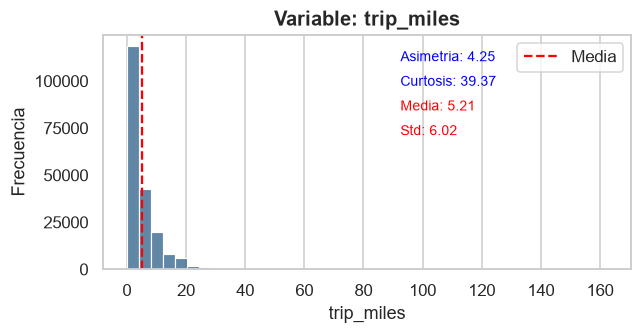

In [10]:
# Histograma con media, varianza y desvio anotados.
# Adaptado de utils/plotting.py -> plot_histograma() de la catedra.
def plot_histograma(data, column, figsize=(6, 3.2), bins=40, muestra=None):
    serie = data[column].dropna()
    if muestra is not None and len(serie) > muestra:
        serie = serie.sample(muestra, random_state=SEMILLA)

    asimetria = serie.skew()
    curtosis = serie.kurt()
    media = serie.mean()
    var = serie.var()
    std = serie.std()

    plt.figure(figsize=figsize)
    plt.grid(axis="y")
    sns.histplot(serie, bins=bins, kde=False, color=AZUL)
    plt.axvline(media, color="red", linestyle="--", label="Media")
    plt.figtext(0.62, 0.80, f"Asimetria: {asimetria:.2f}", fontsize=9, color="blue")
    plt.figtext(0.62, 0.73, f"Curtosis: {curtosis:.2f}", fontsize=9, color="blue")
    plt.figtext(0.62, 0.66, f"Media: {media:.2f}", fontsize=9, color="red")
    plt.figtext(0.62, 0.59, f"Std: {std:.2f}", fontsize=9, color="red")
    plt.title(f"Variable: {column}")
    plt.xlabel(column)
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.tight_layout()


plot_histograma(df, "trip_miles", muestra=MUESTRA_GRAFICOS)
guardar_figura("00_histograma_trip_miles")
plt.show()

### Qué nos dice esta tabla

Tres cosas saltan a la vista:

**1. Todas las distribuciones son fuertemente asimétricas a derecha.** La media es siempre
mayor que la mediana y la asimetría es positiva y grande. Por ejemplo, el viaje típico es
de unas 3 millas (mediana), pero el máximo llega a más de 300. Esto tiene una consecuencia
práctica: **los histogramas van a necesitar escala logarítmica** para verse, y la media es
un mal resumen — conviene usar la mediana.

**2. Hay valores negativos donde no debería haberlos.** `base_passenger_fare` tiene mínimo
negativo, y `espera_min` también. Una tarifa negativa o una espera negativa no existen en
la realidad: son **errores**, no outliers. Los tratamos en §8.

**3. `tips` tiene mediana 0.** La mayoría de los viajes no recibe propina. Ese cero es
**información real**, no un dato faltante — es la distinción que vamos a usar en §9 para
definir el problema de clasificación.

---

# §5. Estadística descriptiva — variables categóricas

Para las categóricas no tiene sentido calcular medias. Lo que se mira es:

- **Frecuencias**: cuántas veces aparece cada categoría
- **Cardinalidad**: cuántas categorías distintas hay (importa mucho para la codificación, §14)
- **Entropía de Shannon**: cuán repartidos están los valores

La **entropía** vale 0 cuando todos los registros tienen el mismo valor (la variable no
aporta nada) y es máxima cuando están perfectamente repartidos. La Clase 5 la menciona
justamente como una de las formas de detectar desbalance *(Clase 5, slide 26: "Análisis de
índices (Entropía de Shannon, Gini)")*, y la implementa en
`clase_05_desbalance.ipynb`.

In [11]:
# Funcion tomada de clase_05_desbalance.ipynb (catedra)
def shannon_entropy(y):
    probs = y.value_counts(normalize=True)
    return -np.sum(probs * np.log2(probs))


def resumen_categorica(serie, nombre, top=5):
    print(f"--- {nombre} ---")
    print(f"    Categorias distintas (cardinalidad): {serie.nunique()}")
    print(f"    Entropia de Shannon: {shannon_entropy(serie):.3f}")
    conteo = serie.value_counts().head(top)
    porcentaje = serie.value_counts(normalize=True).head(top) * 100
    for categoria in conteo.index:
        print(f"       {str(categoria):<28} {conteo[categoria]:>12,}  ({porcentaje[categoria]:5.2f}%)")
    print()


for nombre in ["empresa", "shared_request_flag", "shared_match_flag",
               "wav_request_flag", "wav_match_flag", "access_a_ride_flag"]:
    resumen_categorica(df[nombre], nombre)

--- empresa ---


    Categorias distintas (cardinalidad): 2
    Entropia de Shannon: 0.877


       Uber                           13,558,357  (70.35%)
       Lyft                            5,713,104  (29.65%)

--- shared_request_flag ---
    Categorias distintas (cardinalidad): 2
    Entropia de Shannon: 0.189


       N                              18,714,269  (97.11%)
       Y                                 557,192  ( 2.89%)

--- shared_match_flag ---
    Categorias distintas (cardinalidad): 2
    Entropia de Shannon: 0.128


       N                              18,930,773  (98.23%)
       Y                                 340,688  ( 1.77%)

--- wav_request_flag ---
    Categorias distintas (cardinalidad): 2
    Entropia de Shannon: 0.031


       N                              19,209,172  (99.68%)
       Y                                  62,289  ( 0.32%)

--- wav_match_flag ---
    Categorias distintas (cardinalidad): 2
    Entropia de Shannon: 0.415


       N                              17,659,460  (91.64%)
       Y                               1,612,001  ( 8.36%)

--- access_a_ride_flag ---
    Categorias distintas (cardinalidad): 2
    Entropia de Shannon: 0.013


       N                              19,249,964  (99.89%)
       Y                                  21,497  ( 0.11%)



In [12]:
# Los ID de zona son categoricos, pero con MUCHAS categorias.
# Esto va a condicionar como los codificamos en la seccion 14.
print("--- Zonas de origen y destino ---")
print(f"    Zonas de origen distintas  (PULocationID): {df['PULocationID'].nunique()}")
print(f"    Zonas de destino distintas (DOLocationID): {df['DOLocationID'].nunique()}")
print()
print("    Top 8 zonas de origen mas frecuentes:")
top_zonas = df["PULocationID"].value_counts().head(8)
for zona, cantidad in top_zonas.items():
    print(f"       zona {zona:>4}: {cantidad:>10,}  ({100 * cantidad / len(df):5.2f}%)")

--- Zonas de origen y destino ---
    Zonas de origen distintas  (PULocationID): 262
    Zonas de destino distintas (DOLocationID): 263

    Top 8 zonas de origen mas frecuentes:


       zona  138:    407,661  ( 2.12%)
       zona  132:    349,773  ( 1.81%)
       zona   61:    262,400  ( 1.36%)
       zona   76:    230,096  ( 1.19%)
       zona   79:    226,042  ( 1.17%)
       zona   37:    222,472  ( 1.15%)
       zona  230:    217,755  ( 1.13%)
       zona  255:    201,526  ( 1.05%)


### Qué nos dice

- **El mercado está repartido 70/30 entre Uber y Lyft.** La entropía de `empresa` es alta
  (cercana a 1, que es el máximo para dos categorías), es decir que las dos empresas están
  bien representadas.
- **Los flags están muy desbalanceados.** Por ejemplo, casi nadie pide viaje compartido.
  Su entropía es baja, lo que anticipa que aportarán poca información.
- **`PULocationID` tiene más de 260 categorías.** Esto es **alta cardinalidad**, y es un
  problema concreto para la codificación: la Clase 4 advierte que one-hot encoding
  *"escala mal con alta cardinalidad"* *(Clase 4, slide 42)*. Lo resolvemos en §14.
- **Ninguna zona supera el 2,2 %.** La demanda está muy repartida geográficamente.

---

# §6. Visualizaciones

> **Consigna:** *"Utilizar los gráficos y técnicas de visualización aprendidos... Emplear el
> gráfico correcto en función del tipo de variable y del análisis que se está realizando.
> Interpretar los resultados obtenidos."*

**El gráfico correcto depende del tipo de variable.** Ese es el criterio que seguimos:

| Qué queremos ver | Tipo de variable | Gráfico correcto |
|---|---|---|
| Cómo se reparte una categórica | categórica | barras |
| Cómo se distribuye una numérica | numérica | histograma |
| Comparar una numérica entre grupos | numérica + categórica | boxplot |
| Relación entre dos numéricas | numérica + numérica | dispersión (scatter) |
| Evolución a lo largo del tiempo | numérica ordenada por tiempo | líneas |

**Nota sobre el muestreo:** los conteos y porcentajes de esta sección se calculan sobre los
19 millones de registros completos. Solo para los gráficos de dispersión usamos una muestra
de 200.000 filas, porque dibujar 19 millones de puntos no se vería mejor y tardaría mucho.
La muestra no cambia ninguna cifra reportada.

   figura guardada: figuras\01_viajes_por_hora.png


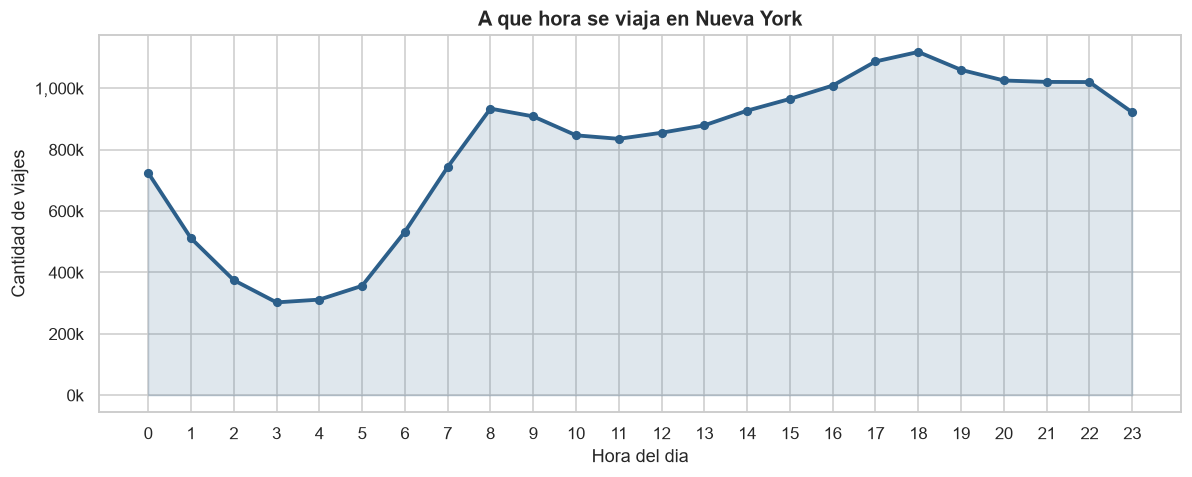

Hora con MENOS viajes: 3h (302,466)
Hora con MAS viajes:   18h (1,118,439)


In [13]:
# --- Viajes por hora del dia (variable temporal -> grafico de lineas) --------
viajes_por_hora = df["hora"].value_counts().sort_index()

plt.figure(figsize=(11, 4.5))
plt.plot(viajes_por_hora.index, viajes_por_hora.values,
         marker="o", color=AZUL, linewidth=2.5, markersize=5)
plt.fill_between(viajes_por_hora.index, viajes_por_hora.values, alpha=0.15, color=AZUL)
plt.title("A que hora se viaja en Nueva York")
plt.xlabel("Hora del dia")
plt.ylabel("Cantidad de viajes")
plt.xticks(range(0, 24))
plt.gca().yaxis.set_major_formatter(lambda x, p: f"{x/1000:,.0f}k")
plt.tight_layout()
guardar_figura("01_viajes_por_hora")
plt.show()

print(f"Hora con MENOS viajes: {viajes_por_hora.idxmin()}h ({viajes_por_hora.min():,})")
print(f"Hora con MAS viajes:   {viajes_por_hora.idxmax()}h ({viajes_por_hora.max():,})")

   figura guardada: figuras\02_viajes_por_dia_semana.png


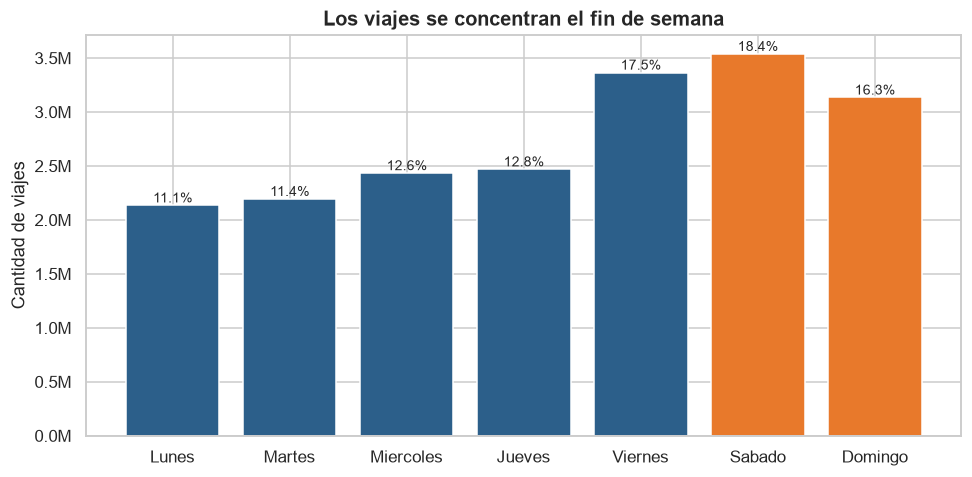

Dia con mas viajes:   Sabado (3,538,584)
Dia con menos viajes: Lunes (2,134,937)
El pico tiene 66% mas viajes que el valle.


In [14]:
# --- Viajes por dia de la semana (categorica ordinal -> barras) -------------
nombres_dias = ["Lunes", "Martes", "Miercoles", "Jueves", "Viernes", "Sabado", "Domingo"]
viajes_por_dia = df["dia_semana"].value_counts().sort_index()

# Coloreamos el fin de semana distinto para que se vea el patron
colores = [AZUL] * 5 + [NARANJA] * 2

plt.figure(figsize=(9, 4.5))
plt.bar(nombres_dias, viajes_por_dia.values, color=colores)
plt.title("Los viajes se concentran el fin de semana")
plt.ylabel("Cantidad de viajes")
plt.gca().yaxis.set_major_formatter(lambda x, p: f"{x/1e6:,.1f}M")
for i, valor in enumerate(viajes_por_dia.values):
    plt.text(i, valor, f"{100*valor/len(df):.1f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
guardar_figura("02_viajes_por_dia_semana")
plt.show()

minimo = viajes_por_dia.min()
maximo = viajes_por_dia.max()
print(f"Dia con mas viajes:   {nombres_dias[viajes_por_dia.idxmax()]} ({maximo:,})")
print(f"Dia con menos viajes: {nombres_dias[viajes_por_dia.idxmin()]} ({minimo:,})")
print(f"El pico tiene {100*(maximo/minimo - 1):.0f}% mas viajes que el valle.")

   figura guardada: figuras\03_distribucion_distancia_log.png


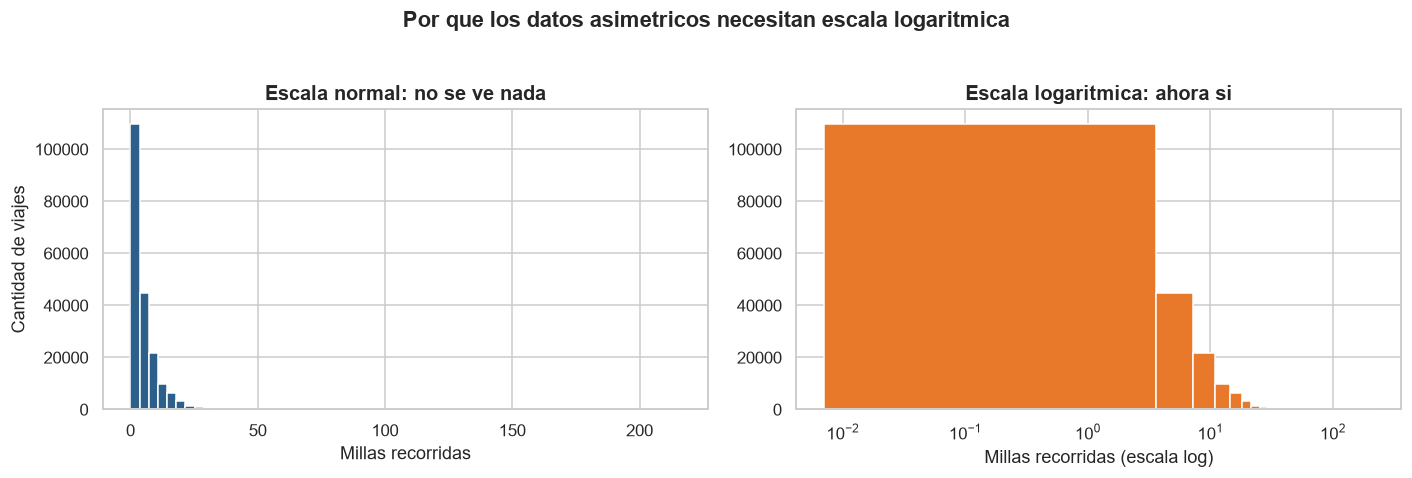

Mediana: 3.15 millas
Media:   5.20 millas  <- la arrastran los viajes largos
Maximo:  441.99 millas


In [15]:
# --- Distribucion de la distancia (numerica asimetrica -> histograma log) ----
# Como la distribucion es muy asimetrica, usamos escala logaritmica en el eje X.
distancias = df.loc[df["trip_miles"] > 0, "trip_miles"]

fig, ejes = plt.subplots(1, 2, figsize=(13, 4.2))

ejes[0].hist(distancias.sample(MUESTRA_GRAFICOS, random_state=SEMILLA),
             bins=60, color=AZUL, edgecolor="white")
ejes[0].set_title("Escala normal: no se ve nada")
ejes[0].set_xlabel("Millas recorridas")
ejes[0].set_ylabel("Cantidad de viajes")

ejes[1].hist(distancias.sample(MUESTRA_GRAFICOS, random_state=SEMILLA),
             bins=60, color=NARANJA, edgecolor="white")
ejes[1].set_xscale("log")
ejes[1].set_title("Escala logaritmica: ahora si")
ejes[1].set_xlabel("Millas recorridas (escala log)")

plt.suptitle("Por que los datos asimetricos necesitan escala logaritmica",
             fontweight="bold", y=1.03)
plt.tight_layout()
guardar_figura("03_distribucion_distancia_log")
plt.show()

print(f"Mediana: {distancias.median():.2f} millas")
print(f"Media:   {distancias.mean():.2f} millas  <- la arrastran los viajes largos")
print(f"Maximo:  {distancias.max():.2f} millas")

   figura guardada: figuras\04_boxplot_por_empresa.png


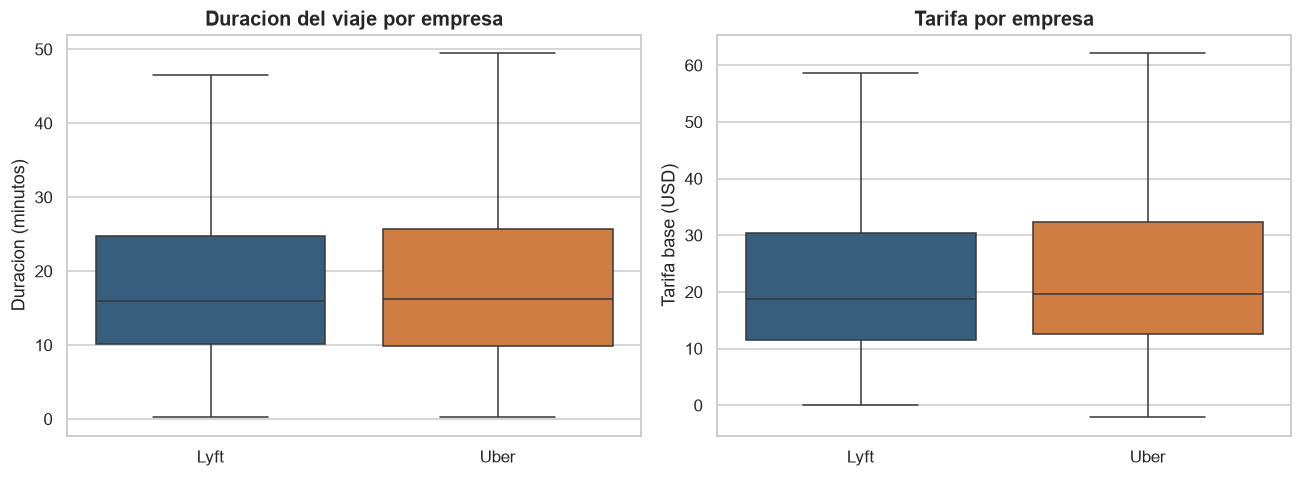

Medianas por empresa (calculadas sobre el dataset COMPLETO):


         duracion_min  base_passenger_fare  trip_miles
empresa                                               
Lyft            16.07                18.75        3.09
Uber            16.20                19.46        3.18


In [16]:
# --- Comparar una numerica entre grupos (numerica + categorica -> boxplot) ---
muestra = df.sample(MUESTRA_GRAFICOS, random_state=SEMILLA)

fig, ejes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.boxplot(data=muestra, x="empresa", y="duracion_min", ax=ejes[0],
            palette=[AZUL, NARANJA], showfliers=False)
ejes[0].set_title("Duracion del viaje por empresa")
ejes[0].set_xlabel("")
ejes[0].set_ylabel("Duracion (minutos)")

sns.boxplot(data=muestra, x="empresa", y="base_passenger_fare", ax=ejes[1],
            palette=[AZUL, NARANJA], showfliers=False)
ejes[1].set_title("Tarifa por empresa")
ejes[1].set_xlabel("")
ejes[1].set_ylabel("Tarifa base (USD)")

plt.tight_layout()
guardar_figura("04_boxplot_por_empresa")
plt.show()

print("Medianas por empresa (calculadas sobre el dataset COMPLETO):")
print(df.groupby("empresa", observed=True)[["duracion_min", "base_passenger_fare",
                                            "trip_miles"]].median().to_string())

   figura guardada: figuras\05_distancia_vs_tarifa.png


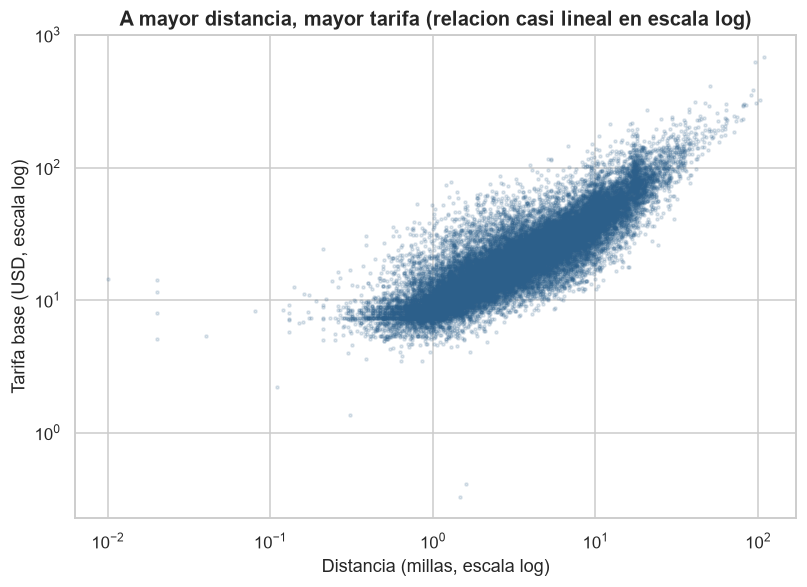

Correlacion de Pearson entre distancia y tarifa: 0.866


In [17]:
# --- Relacion entre dos numericas (numerica + numerica -> dispersion) -------
# Usamos una muestra: dibujar 19 millones de puntos no se veria mejor.
muestra_scatter = df.sample(30_000, random_state=SEMILLA)

plt.figure(figsize=(7.5, 5.5))
plt.scatter(muestra_scatter["trip_miles"], muestra_scatter["base_passenger_fare"],
            s=4, alpha=0.15, color=AZUL)
plt.xscale("log")
plt.yscale("log")
plt.title("A mayor distancia, mayor tarifa (relacion casi lineal en escala log)")
plt.xlabel("Distancia (millas, escala log)")
plt.ylabel("Tarifa base (USD, escala log)")
plt.tight_layout()
guardar_figura("05_distancia_vs_tarifa")
plt.show()

correlacion = df[["trip_miles", "base_passenger_fare"]].corr().iloc[0, 1]
print(f"Correlacion de Pearson entre distancia y tarifa: {correlacion:.3f}")

### Interpretación de los gráficos

**El patrón semanal es de ocio, no de trabajo.** El sábado tiene un 66 % más de viajes que
el lunes. Si el uso fuera principalmente para ir a trabajar, el pico estaría entre semana.

**El patrón horario lo confirma.** El valle está a las 3 de la mañana y el pico a las 18h,
pero lo llamativo es que la actividad se mantiene alta hasta pasada la medianoche. Hay un
repunte matinal a las 8-9h, pero es mucho menor que el vespertino.

**Los datos son fuertemente asimétricos.** El gráfico de la izquierda del tercer panel
muestra el problema: con escala normal, todos los viajes se amontonan contra el eje y no se
distingue nada. Con escala logarítmica aparece la forma real de la distribución. Esto no es
un detalle estético: **es la razón por la que en §14 vamos a discretizar por percentiles y
no por intervalos iguales.**

**Uber y Lyft se comportan casi igual.** Las medianas de duración, tarifa y distancia son
muy parecidas. La empresa, por sí sola, no parece explicar gran cosa.

**Distancia y tarifa están muy correlacionadas.** Es esperable — la tarifa se calcula en
buena medida a partir de la distancia. Esto va a importar en §17: dos variables muy
correlacionadas son **redundantes** entre sí.

---

# §7. Valores faltantes y su tipo

> **Consigna:** *"Identificar errores, outliers (anomalías), valores faltantes **y su tipo
> (MCAR, MAR, MNAR, estructural/por diseño)**."*

Esta es una de las partes más importantes del trabajo. No alcanza con contar los faltantes:
hay que **explicar por qué faltan**, porque de eso depende cómo tratarlos.

## Los cuatro tipos, con las definiciones textuales de la Clase 3

La cátedra inventó una regla mnemotécnica para cada sigla, que anotamos porque ayuda:

**MCAR** — *Missing Completely at Random* — **M**uestra **C**on **A**usencia **R**andom
*(Clase 3, slide 51)*
> *"El valor falta por una causa al azar y su falta es independiente de los datos.
> Es un mecanismo que no introduce sesgo."*
>
> *Ejemplo de la clase: una encuesta de salarios donde el formulario falla al azar.*

**MAR** — *Missing at Random* — **M**uestra **A**usente por **R**elación
*(Clase 3, slide 52)*
> *"La falta del valor se relaciona con los datos de otras columnas (hay un patrón)."*
>
> *Ejemplo de la clase: los encuestados mayores de 40 son menos propensos a divulgar su
> salario. El faltante de `salario` se explica por la columna `edad`.*

**MNAR** — *Missing not at Random* — **M**uestra **N**o **A**parece debido a su **R**esultado
*(Clase 3, slide 53)*
> *"La falta del valor depende del dato no observado y se debe a una causa específica que
> debe ser investigada."*
>
> *Ejemplo de la clase: las personas con salarios más altos evitan contestar. El faltante
> de `salario` se explica por el propio salario, que no vemos.*

**Estructural / por diseño** *(Clase 3, slide 54)*
> *"La falta del valor se debe a que el dato no existe. Tiene sentido que no esté."*
>
> *Ejemplo de la clase: el año de graduación queda en blanco para los que no se graduaron.*

> ⚠️ **La diferencia entre MAR y estructural es sutil pero decisiva.** En los dos casos el
> faltante se explica por otra columna. La diferencia está en **si el dato existe o no**:
> en MAR existe pero no se registró; en estructural directamente no tiene sentido que
> exista. Vamos a ver que en nuestro caso esa distinción cambia la respuesta.

## Cómo se identifican

La Clase 3 da el método concreto *(Clase 3, slide 55)*:

> - **MCAR:** *"Filtrado / agrupamiento (por ej, es MCAR si el porcentaje de faltantes es
>   aprox. el mismo al agrupar de distintas maneras)."*
> - **Estructural:** *"consultar la documentación de recolección."*
> - **MNAR** *"es la más difícil de detectar. La dejamos como última opción si no hay
>   evidencia clara de ninguna de las otras causas."*

Vamos a aplicar exactamente ese método, usando la función `nulos_por_grupo()` que la
cátedra define en `clase_03_analisis _faltantes_outliers.ipynb`.

In [18]:
# Recuento de faltantes, como en clase_03 de la catedra
print("Cantidad de faltantes por columna:")
print(df.isna().sum()[df.isna().sum() > 0].to_string())
print()
print("Porcentaje de faltantes por columna:")
porcentajes = (df.isna().mean().round(4) * 100)
print(porcentajes[porcentajes > 0].to_string())
print()
print(f"Columnas SIN ningun faltante: {df.notna().all().sum()} de {df.shape[1]}")

Cantidad de faltantes por columna:


originating_base_num    5692756
velocidad_mph                 1

Porcentaje de faltantes por columna:


originating_base_num   29.54



Columnas SIN ningun faltante: 29 de 31


   figura guardada: figuras\06a_missingno_bar.png


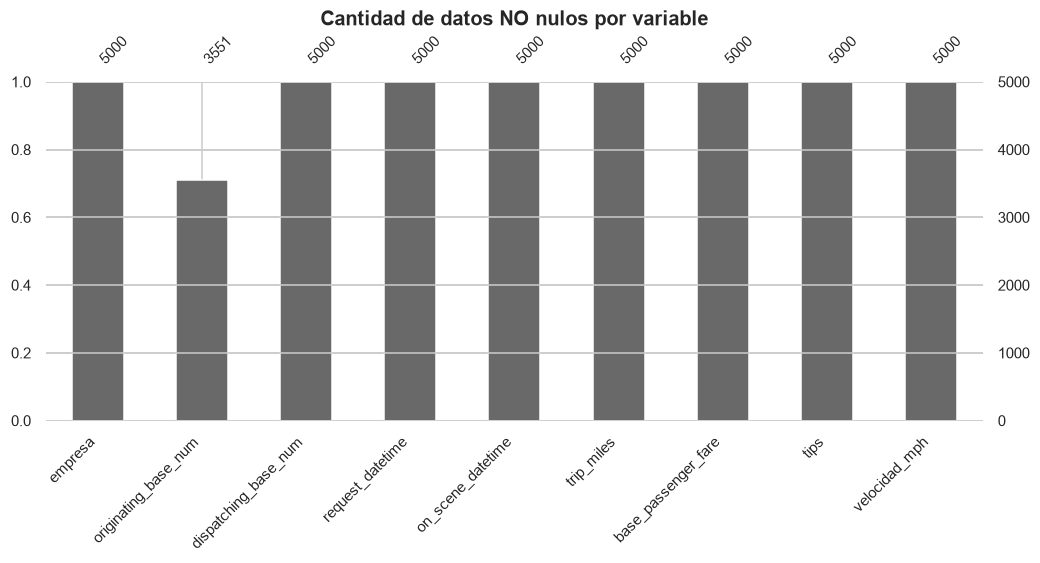

   figura guardada: figuras\06_mapa_faltantes.png


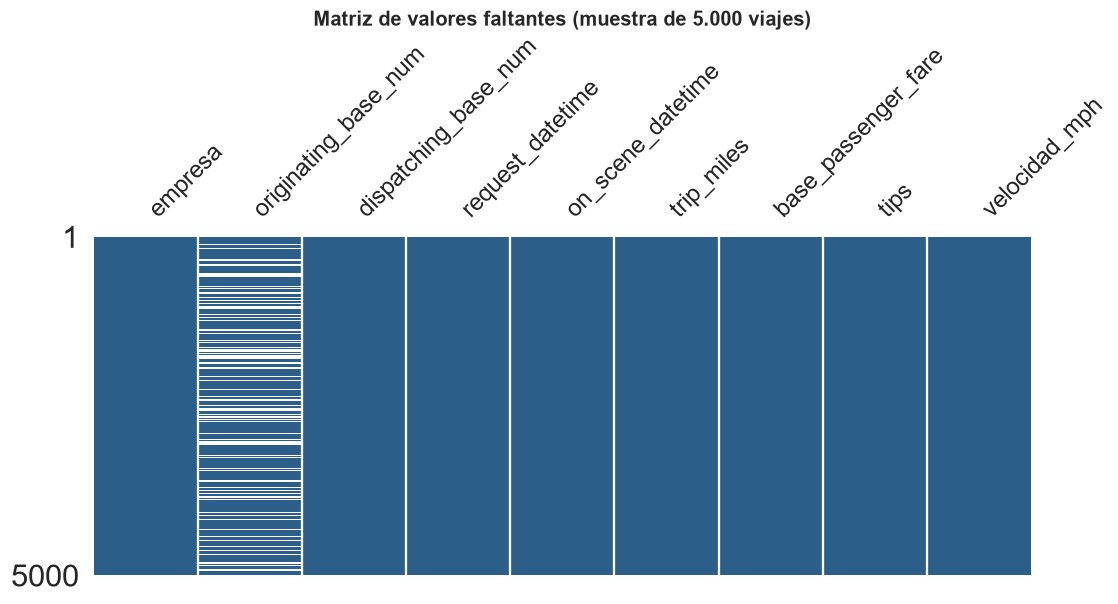

In [19]:
# Visualizacion con missingno, como en clase_03 de la catedra
import missingno as msno

muestra_faltantes = df.sample(5_000, random_state=SEMILLA)
columnas_a_mostrar = ["empresa", "originating_base_num", "dispatching_base_num",
                      "request_datetime", "on_scene_datetime", "trip_miles",
                      "base_passenger_fare", "tips", "velocidad_mph"]

msno.bar(muestra_faltantes[columnas_a_mostrar], fontsize=10, figsize=(11, 4))
plt.title("Cantidad de datos NO nulos por variable", fontsize=13)
guardar_figura("06a_missingno_bar")
plt.show()

msno.matrix(muestra_faltantes[columnas_a_mostrar], figsize=(11, 4),
            color=(0.17, 0.37, 0.54), sparkline=False)
plt.title("Matriz de valores faltantes (muestra de 5.000 viajes)", fontsize=13)
guardar_figura("06_mapa_faltantes")
plt.show()

In [20]:
# Funcion tomada de clase_03_analisis _faltantes_outliers.ipynb (catedra).
# Calcula el porcentaje de nulos de una columna, agrupando por otras.
def nulos_por_grupo(df, grupo_cols, target_col):
    agrupar_nulos = (
        df.groupby(grupo_cols, observed=True)[target_col]
        .apply(lambda x: x.isnull().mean() * 100)
        .reset_index(name=f'porcentaje_nulos_{target_col}')
    )
    return agrupar_nulos


# Clase 3, slide 55: "es MCAR si el porcentaje de faltantes es aprox. el mismo
# al agrupar de distintas maneras". Probamos con VARIOS agrupamientos:
print("Nulos de originating_base_num por EMPRESA:")
print(nulos_por_grupo(df, "empresa", "originating_base_num").to_string(index=False))
print()
print("Nulos de originating_base_num por DIA DE LA SEMANA:")
print(nulos_por_grupo(df, "dia_semana", "originating_base_num").to_string(index=False))
print()
print("Nulos de originating_base_num por si PIDIO VIAJE COMPARTIDO:")
print(nulos_por_grupo(df, "shared_request_flag", "originating_base_num").to_string(index=False))

Nulos de originating_base_num por EMPRESA:


empresa  porcentaje_nulos_originating_base_num
   Lyft                                  99.64
   Uber                                   0.00

Nulos de originating_base_num por DIA DE LA SEMANA:


 dia_semana  porcentaje_nulos_originating_base_num
          0                                  28.43
          1                                  28.12
          2                                  29.02
          3                                  29.00
          4                                  29.75
          5                                  30.49
          6                                  30.83

Nulos de originating_base_num por si PIDIO VIAJE COMPARTIDO:


shared_request_flag  porcentaje_nulos_originating_base_num
                  N                                  30.41
                  Y                                   0.23


In [21]:
# Lo mismo, visto como tabla de contingencia
tabla = pd.crosstab(df["empresa"],
                    df["originating_base_num"].isna(),
                    rownames=["Empresa"],
                    colnames=["originating_base_num esta vacio"])

print("CROSSTAB: faltantes de originating_base_num segun la empresa")
print("=" * 62)
print(tabla.to_string())

CROSSTAB: faltantes de originating_base_num segun la empresa
originating_base_num esta vacio     False    True 
Empresa                                           
Lyft                                20348  5692756
Uber                             13558357        0


### Paso 1: ¿es MCAR? — **No**

Miremos los tres agrupamientos que acabamos de hacer:

- **Por día de la semana:** el porcentaje de faltantes es prácticamente el mismo todos los
  días (~28 % a 31 %). Si solo hubiéramos mirado esto, habríamos concluido MCAR.
- **Por viaje compartido:** también parejo.
- **Por empresa:** **0 % en Uber contra 99,6 % en Lyft.**

El criterio de la Clase 3 slide 55 dice que es MCAR *"si el porcentaje de faltantes es
aprox. el mismo al agrupar de distintas maneras"* — y al agrupar por empresa **no lo es en
absoluto**. Esto **descarta MCAR**.

> 💡 **La lección de método:** si hubiéramos agrupado por una sola variable habríamos llegado
> a la conclusión equivocada. Por eso la Clase 3 dice *"al agrupar de distintas maneras"*,
> en plural.

### Paso 2: ¿es estructural? — Hay que ir a la documentación

La Clase 3 slide 55 indica que para confirmar un faltante estructural hay que
**"consultar la documentación de recolección"**. Así que fuimos al diccionario oficial del
TLC (`data_dictionary_trip_records_hvfhs.pdf`). Dice, textualmente:

> `originating_base_num`: *"Base number of the base that received the original trip
> request."*

**Y nada más.** El diccionario **no dice** que Lyft no reporte este campo, ni que el dato no
exista para sus viajes. Simplemente define qué significa la columna.

Es decir: **la documentación no confirma que sea estructural.** Y como la definición de
estructural exige que *"el dato no exista"*, no podemos afirmarlo solo porque nos parezca
razonable. Lo verificamos con los datos.

### Paso 3: la prueba empírica que decide

Si el dato **no existiera** para Lyft, tendría que faltar en el **100 %** de sus viajes.
Veamos si es así.

In [22]:
# Si el dato NO EXISTIERA para Lyft, deberia faltar en el 100% de sus viajes.
print("Registros de Lyft CON valor en originating_base_num:")
lyft = df[df["empresa"] == "Lyft"]
con_valor = int(lyft["originating_base_num"].notna().sum())
print(f"   {con_valor:,} de {len(lyft):,}  ({100*con_valor/len(lyft):.2f}%)")
print()
print("Comparamos originating_base_num con dispatching_base_num, por empresa:")
for nombre in ["Uber", "Lyft"]:
    sub = df[df["empresa"] == nombre]
    print()
    print(f"   {nombre}:")
    # .unique() sobre una columna 'category' devuelve solo las categorias presentes
    bases_disp = list(sub["dispatching_base_num"].dropna().unique())
    print(f"      dispatching_base_num : {len(bases_disp)} base(s) -> {bases_disp}")
    vals = sub["originating_base_num"].dropna()
    print(f"      originating_base_num : {vals.nunique()} base(s) distinta(s) "
          f"en {len(vals):,} registros con valor")
    if len(vals) > 0:
        print(f"      valor mas frecuente  : {vals.value_counts().index[0]}")

Registros de Lyft CON valor en originating_base_num:


   20,348 de 5,713,104  (0.36%)

Comparamos originating_base_num con dispatching_base_num, por empresa:



   Uber:
      dispatching_base_num : 1 base(s) -> ['B03404']
      originating_base_num : 3 base(s) distinta(s) en 13,558,357 registros con valor
      valor mas frecuente  : B03404



   Lyft:
      dispatching_base_num : 1 base(s) -> ['B03406']
      originating_base_num : 1 base(s) distinta(s) en 20,348 registros con valor
      valor mas frecuente  : B03406


### El veredicto: es **MAR**, no estructural

La prueba es concluyente: **Lyft sí informa `originating_base_num` en unos 20.000 viajes**
(el 0,36 % de los suyos). Si el dato no existiera, faltaría en el 100 % de los casos, no en
el 99,64 %.

Eso **descarta que sea estructural**: la definición de la Clase 3 slide 54 exige que
*"el dato no exista"*, y acá existe — simplemente casi nunca se registra.

Nos queda entonces la definición de MAR *(Clase 3, slide 52)*:

> *"La falta del valor se relaciona con los datos de otras columnas (hay un patrón)."*

Es exactamente nuestro caso: **el faltante se explica por la columna `empresa`**. Es el
mismo esquema que el ejemplo de la clase, donde el faltante de `salario` se explicaba por
la columna `edad`. Acá el faltante de `originating_base_num` se explica por `empresa`.

**Clasificación final: MAR — Muestra Ausente por Relación.**

> 📌 **Por qué vale la pena haber hecho el paso 3.** Era tentador quedarse en "Lyft no usa
> ese esquema, es estructural": suena razonable y encaja con la intuición. Pero la Clase 3
> pide *consultar la documentación*, y la documentación no lo dice. Al ir a verificarlo
> contra los datos, apareció el contraejemplo. **Una hipótesis plausible no es una
> comprobación.**

### Un detalle sobre la documentación que conviene tener presente

El mismo diccionario del TLC define `on_scene_datetime` como
*"Date/time when driver arrived at the pick-up location **(Accessible Vehicles-only)**"*.
Según eso, esa columna debería estar vacía en todos los viajes que no son de vehículo
accesible. **En agosto 2025 no tiene ni un solo faltante.**

Es decir que la documentación oficial y los datos no coinciden. Es un recordatorio útil:
**la documentación se consulta, pero también se verifica contra los datos.**

### Por qué esto importa en la práctica

**Imputar esta columna sería un error de todos modos.** No porque el dato no exista, sino
porque el hecho de que falte coincide casi perfectamente con "ser Lyft": la columna es en
los hechos **un duplicado de la variable `empresa`**: es información redundante.

Además, cuando el valor está presente, **coincide con `dispatching_base_num`** en las dos
empresas. Así que la columna tampoco aporta nada respecto de esa otra.

**Decisión: se descarta la columna.** Por redundante, no por estructural. La justificamos
de nuevo en §10.

---

# §8. Errores y outliers

> **Consigna:** *"Identificar errores, outliers (anomalías)..."* y *"Detectar y manejar los
> outliers utilizando técnicas estadísticas o visuales apropiadas."*

Acá hay que distinguir **dos cosas que se parecen pero no son lo mismo**:

- Un **error** es un valor **imposible**: una tarifa negativa, una espera negativa. No puede
  existir en la realidad. Se detecta con **conocimiento del dominio**, no con estadística.
- Un **outlier** es un valor **raro pero posible**: un viaje de 300 millas es extraño, pero
  puede haber ocurrido. Se detecta con **métodos estadísticos**.

La diferencia importa porque **se tratan distinto**: el error se elimina o se corrige; el
outlier hay que decidir si es legítimo o no.

La Clase 3 presenta dos métodos estadísticos, que aplicamos los dos.

In [23]:
# --- ERRORES: valores imposibles segun el dominio ---------------------------
reglas_de_error = {
    "Espera negativa (subio antes de pedir)": df["espera_min"] < 0,
    "Tarifa igual a cero":                    df["base_passenger_fare"] == 0,
    "Tarifa negativa":                        df["base_passenger_fare"] < 0,
    "Pago al conductor negativo":             df["driver_pay"] < 0,
    "Distancia cero o negativa":              df["trip_miles"] <= 0,
    "Duracion cero o negativa":               df["duracion_min"] <= 0,
    "Velocidad mayor a 80 mph":               df["velocidad_mph"] > 80,
}

print("ERRORES DETECTADOS (valores imposibles)")
print("=" * 66)
for descripcion, condicion in reglas_de_error.items():
    cantidad = int(condicion.sum())
    print(f"   {descripcion:<42} {cantidad:>9,}  ({100*cantidad/len(df):6.3f}%)")

ERRORES DETECTADOS (valores imposibles)
   Espera negativa (subio antes de pedir)       224,310  ( 1.164%)
   Tarifa igual a cero                          185,443  ( 0.962%)
   Tarifa negativa                                  772  ( 0.004%)
   Pago al conductor negativo                        25  ( 0.000%)
   Distancia cero o negativa                      2,220  ( 0.012%)


   Duracion cero o negativa                           1  ( 0.000%)
   Velocidad mayor a 80 mph                          13  ( 0.000%)


In [24]:
# --- METODO 1: rango intercuartil (IQR) -------------------------------------
# Codigo tomado de clase_03 y clase_04_tratamiento_outliers.ipynb (catedra):
#   outliers son los datos menores a (Q1 - 1.5*IQR) o mayores a (Q3 + 1.5*IQR)
variables_outliers = ["trip_miles", "duracion_min", "espera_min",
                      "base_passenger_fare", "driver_pay", "velocidad_mph"]

df_num = df[variables_outliers].sample(MUESTRA_GRAFICOS, random_state=SEMILLA)

Q1 = df_num.quantile(0.25)
Q3 = df_num.quantile(0.75)
IQR = Q3 - Q1

outliers_iqr = (df_num < (Q1 - 1.5 * IQR)) | (df_num > (Q3 + 1.5 * IQR))

print("METODO IQR (Clase 3)")
print("=" * 72)
for var in variables_outliers:
    limite_inf = Q1[var] - 1.5 * IQR[var]
    limite_sup = Q3[var] + 1.5 * IQR[var]
    cantidad = int(outliers_iqr[var].sum())
    print(f"   {var:<22} <{limite_inf:>9,.2f} o >{limite_sup:>9,.2f}   "
          f"-> {cantidad:>7,} outliers ({100*cantidad/len(df_num):5.2f}%)")

METODO IQR (Clase 3)
   trip_miles             <    -5.89 o >    14.11   ->  14,301 outliers ( 7.15%)
   duracion_min           <   -13.15 o >    48.58   ->   8,902 outliers ( 4.45%)
   espera_min             <    -1.50 o >     9.57   ->  12,670 outliers ( 6.33%)
   base_passenger_fare    <   -17.15 o >    61.09   ->  14,152 outliers ( 7.08%)
   driver_pay             <   -16.22 o >    51.70   ->  11,373 outliers ( 5.69%)
   velocidad_mph          <    -2.79 o >    29.01   ->   9,218 outliers ( 4.61%)


In [25]:
# --- METODO 2: desviacion estandar (Clase 3) --------------------------------
# Codigo tomado de clase_03: outliers fuera de la media +/- 3 desvios
mean = df_num.mean()
std = df_num.apply(lambda x: np.nanstd(x, ddof=1))

outliers_std = (df_num < (mean - 3 * std)) | (df_num > (mean + 3 * std))

print("METODO DESVIACION ESTANDAR (Clase 3)")
print("=" * 72)
for var in variables_outliers:
    cantidad = int(outliers_std[var].sum())
    print(f"   {var:<22} <{mean[var] - 3*std[var]:>9,.2f} o >{mean[var] + 3*std[var]:>9,.2f}   "
          f"-> {cantidad:>7,} outliers ({100*cantidad/len(df_num):5.2f}%)")

print()
print("COMPARACION DE LOS DOS METODOS")
print("=" * 52)
print(f"{'variable':<22}{'IQR':>13}{'std (3 sigma)':>17}")
print("-" * 52)
for var in variables_outliers:
    print(f"{var:<22}{outliers_iqr[var].sum():>13,}{outliers_std[var].sum():>17,}")

METODO DESVIACION ESTANDAR (Clase 3)
   trip_miles             <   -12.87 o >    23.28   ->   3,184 outliers ( 1.59%)
   duracion_min           <   -22.55 o >    62.10   ->   3,374 outliers ( 1.69%)
   espera_min             <    -5.46 o >    14.24   ->   4,313 outliers ( 2.16%)
   base_passenger_fare    <   -47.15 o >   100.27   ->   3,849 outliers ( 1.92%)
   driver_pay             <   -34.10 o >    75.80   ->   3,359 outliers ( 1.68%)
   velocidad_mph          <    -7.15 o >    35.11   ->   2,935 outliers ( 1.47%)

COMPARACION DE LOS DOS METODOS
variable                        IQR    std (3 sigma)
----------------------------------------------------
trip_miles                   14,301            3,184
duracion_min                  8,902            3,374
espera_min                   12,670            4,313
base_passenger_fare          14,152            3,849
driver_pay                   11,373            3,359
velocidad_mph                 9,218            2,935


   figura guardada: figuras\07_boxplots_outliers.png


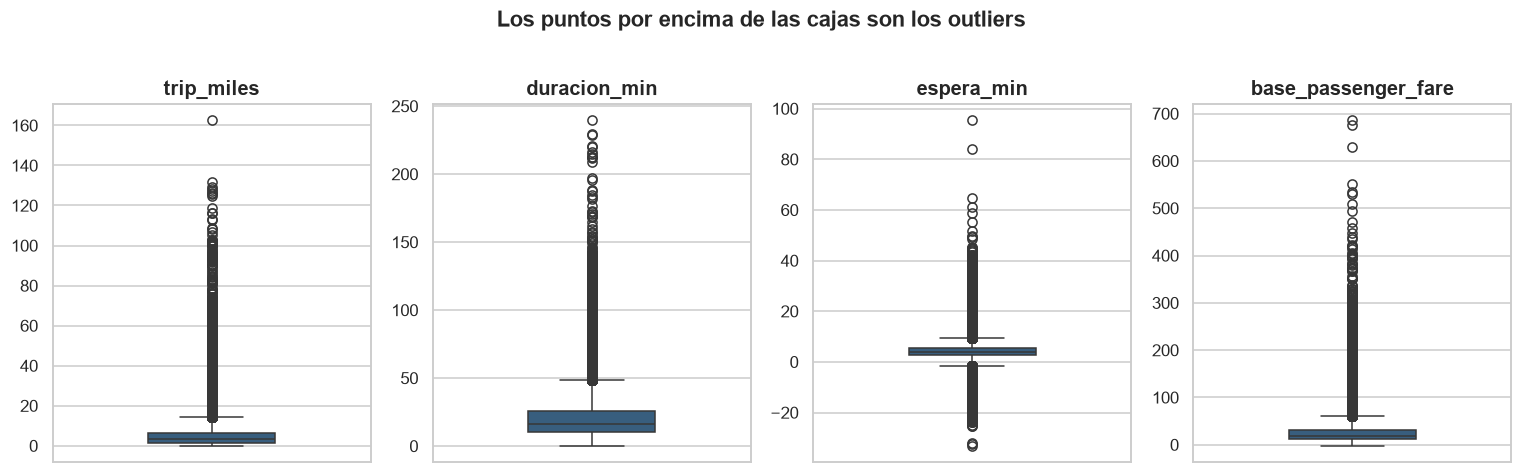

In [26]:
# Visualizacion con boxplots (Clase 3)
fig, ejes = plt.subplots(1, 4, figsize=(14, 4.2))
for eje, variable in zip(ejes, ["trip_miles", "duracion_min",
                                "espera_min", "base_passenger_fare"]):
    sns.boxplot(y=df_num[variable], ax=eje, color=AZUL, width=0.4)
    eje.set_title(variable)
    eje.set_ylabel("")

plt.suptitle("Los puntos por encima de las cajas son los outliers",
             fontweight="bold", y=1.02)
plt.tight_layout()
guardar_figura("07_boxplots_outliers")
plt.show()

   figura guardada: figuras\07b_hist_desvios.png


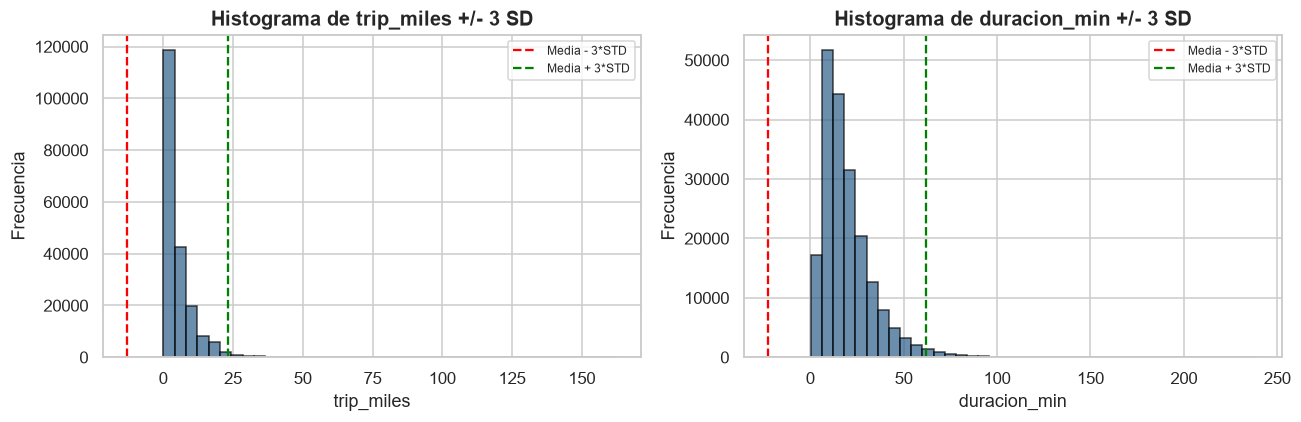

In [27]:
# Histograma con las bandas de +/- 3 desvios.
# Funcion plot_hist_with_std() tomada de clase_03 (catedra).
def plot_hist_with_std(ax, data, varname, mean, std):
    ax.hist(data, bins=40, edgecolor="black", alpha=0.7, color=AZUL)
    ax.axvline(mean[varname] - 3*std[varname], color="red", linestyle="--",
               label="Media - 3*STD")
    ax.axvline(mean[varname] + 3*std[varname], color="green", linestyle="--",
               label="Media + 3*STD")
    ax.set_xlabel(varname)
    ax.set_ylabel("Frecuencia")
    ax.set_title(f"Histograma de {varname} +/- 3 SD")
    ax.legend(fontsize=8)


fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plot_hist_with_std(ax[0], df_num["trip_miles"], "trip_miles", mean, std)
plot_hist_with_std(ax[1], df_num["duracion_min"], "duracion_min", mean, std)
plt.tight_layout()
guardar_figura("07b_hist_desvios")
plt.show()

### Interpretación: cuáles son errores y cuáles outliers legítimos

**Son errores y hay que eliminarlos:**

- **Espera negativa** (1,16 %): el pasajero habría subido al auto *antes* de pedirlo.
  Imposible. Probablemente sean relojes desincronizados entre el celular y el servidor.
- **Tarifa cero o negativa** (~0,97 %): viajes cancelados, reembolsos o ajustes contables.
  No son viajes reales con precio.
- **Distancia o duración cero**: no hubo viaje.
- **Velocidad mayor a 80 mph**: imposible en el tránsito de Nueva York.

**Son outliers legítimos y hay que conservarlos:**

- Los viajes de más de 100 millas: existen, son traslados a otros estados.
- Las tarifas altas: corresponden a esos viajes largos.

**Los dos métodos no coinciden, y eso es informativo.** El IQR marca muchos más outliers que
el criterio de los 3 desvíos. La razón es que **el IQR asume una distribución
aproximadamente simétrica**, y ya vimos en §4 y §6 que estas distribuciones son fuertemente
asimétricas. Eliminar todo lo que el IQR marca sería descartar datos perfectamente válidos.

**Por eso vamos a usar ambos métodos como diagnóstico, pero para el tratamiento (§13) vamos
a recortar por percentiles**, que se adapta mejor a distribuciones asimétricas.

---

# §9. El problema de Machine Learning

> **Consigna:** *"Plantear un posible problema de ML supervisado a partir de los datos
> elegidos. Describir el problema de clasificación o de regresión. Definir la variable
> target."*

## El problema

> **¿Podemos predecir si un pasajero va a dejar propina?**

Es un problema de **clasificación binaria**: la respuesta es sí o no. La Clase 7 lo define
así: *"Clasificación: la etiqueta es una categoría"* *(Clase 7, slide 4)*.

## La variable target

```
dio_propina = 1  si  tips > 0     (dejó propina)
dio_propina = 0  si  tips = 0     (no dejó propina)
```

## Por qué elegimos este problema

1. **Tiene sentido de negocio.** Saber qué viajes tienden a recibir propina sirve para
   entender el comportamiento del pasajero.
2. **La target está desbalanceada**, lo que nos permite trabajar el tema de desbalance de
   clases que pide la consigna (§16).
3. **No es trivial.** A diferencia de predecir la tarifa (que se calcula casi
   mecánicamente a partir de la distancia), la propina depende de factores más sutiles.

## Cuándo se haría la predicción

**Al terminar el viaje.** En ese momento ya se conocen la distancia, la duración, la tarifa
y las zonas. Esto es importante porque define qué variables podemos usar: la Clase 7 lo
plantea como una de las preguntas clave para seleccionar features *(Clase 7, slide 7)*:

> *"¿Voy a tener este dato al momento de predecir?"*

In [28]:
# Creamos la variable target
df["dio_propina"] = (df["tips"] > 0).astype(int)

conteo = df["dio_propina"].value_counts().sort_index()
porcentaje = df["dio_propina"].value_counts(normalize=True).sort_index() * 100

print("DISTRIBUCION DE LA VARIABLE TARGET")
print("=" * 50)
print(f"   Clase 0 (NO dejo propina): {conteo[0]:>12,}  ({porcentaje[0]:5.2f}%)")
print(f"   Clase 1 (SI dejo propina): {conteo[1]:>12,}  ({porcentaje[1]:5.2f}%)")
print()
print(f"   Ratio de desbalance: 1 : {conteo[0] / conteo[1]:.2f}")
print(f"   Entropia de Shannon: {shannon_entropy(df['dio_propina']):.4f}  (maximo = 1)")

DISTRIBUCION DE LA VARIABLE TARGET
   Clase 0 (NO dejo propina):   15,701,443  (81.48%)
   Clase 1 (SI dejo propina):    3,570,018  (18.52%)

   Ratio de desbalance: 1 : 4.40
   Entropia de Shannon: 0.6914  (maximo = 1)


   figura guardada: figuras\08_desbalance_target.png


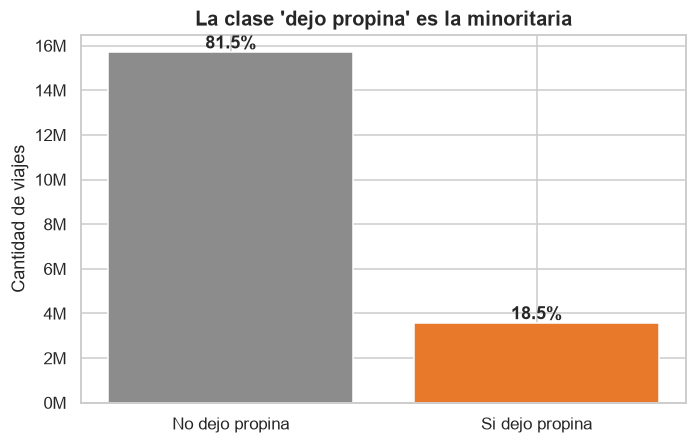

In [29]:
# Grafico de barras de la target, con countplot como en clase_05_desbalance
plt.figure(figsize=(6.5, 4.2))
barras = plt.bar(["No dejo propina", "Si dejo propina"], conteo.values,
                 color=[GRIS, NARANJA])
plt.title("La clase 'dejo propina' es la minoritaria")
plt.ylabel("Cantidad de viajes")
plt.gca().yaxis.set_major_formatter(lambda x, p: f"{x/1e6:,.0f}M")
for barra, pct in zip(barras, porcentaje.values):
    plt.text(barra.get_x() + barra.get_width()/2, barra.get_height(),
             f"{pct:.1f}%", ha="center", va="bottom", fontweight="bold")
plt.tight_layout()
guardar_figura("08_desbalance_target")
plt.show()

In [30]:
# ¿La propina depende de la empresa?
tabla_propina = pd.crosstab(df["empresa"], df["dio_propina"], normalize="index") * 100
tabla_propina.columns = ["No dejo propina (%)", "Si dejo propina (%)"]
print("TASA DE PROPINA POR EMPRESA")
print("=" * 50)
print(tabla_propina.to_string())
print()

propina_media = df.loc[df["tips"] > 0].groupby("empresa", observed=True)["tips"].mean()
print("Propina promedio (solo entre los que dejaron):")
for empresa, valor in propina_media.items():
    print(f"   {empresa:<6}: ${valor:.2f}")

TASA DE PROPINA POR EMPRESA
         No dejo propina (%)  Si dejo propina (%)
empresa                                          
Lyft                   80.66                19.34
Uber                   81.82                18.18



Propina promedio (solo entre los que dejaron):
   Lyft  : $6.14
   Uber  : $6.18


### Qué observamos

**El desbalance es de 1 a 4,4.** Casi el 82 % de los viajes no recibe propina. Esto no es un
desbalance extremo — la Clase 5 reserva ese término para casos como 1:1000, donde sugiere
*"considerar recolectar más datos"* *(Clase 5, slide 27)*. El nuestro es moderado y se puede
tratar con las técnicas habituales, que aplicamos en §16.

**La empresa casi no influye.** Lyft tiene una tasa de propina levemente superior a Uber,
pero la diferencia es de aproximadamente un punto porcentual, y el monto promedio de la
propina es prácticamente idéntico. Esto sugiere que la propina **depende más del contexto
del viaje que de la plataforma**, que es una hipótesis interesante para verificar en §17.

---

# §10. Limpieza general del dataset

> **Consigna:** *"Realizar una limpieza general del dataset, eliminando o corrigiendo datos
> inconsistentes o irrelevantes."*

Aplicamos las decisiones que fuimos justificando en §7 y §8:

| Qué hacemos | Por qué |
|---|---|
| Eliminar filas con **errores de dominio** | Son valores imposibles (§8) |
| Descartar `originating_base_num` | Faltante estructural, redundante con `empresa` (§7) |
| Descartar las columnas de **importes desagregados** | Son componentes del precio, no información del viaje |
| Descartar `tips` de los features | **Es la target**: usarla sería hacer trampa |

## Sobre la última fila: la fuga de datos

`tips` no puede estar entre las variables predictoras, porque la target se calcula
directamente de ella (`dio_propina = tips > 0`). Un modelo que viera `tips` acertaría el
100 % sin haber aprendido nada. A esto se lo llama **fuga de datos** (*data leakage*).

Por el mismo motivo descartamos los importes desagregados (`bcf`, `sales_tax`,
`congestion_surcharge`, `airport_fee`, `cbd_congestion_fee`): son recargos que se calculan
a partir de la tarifa, así que repiten información que ya está en `base_passenger_fare`.

In [31]:
filas_originales = len(df)

# --- Paso 1: marcamos las filas con errores de dominio ---------------------
# Todavia no copiamos nada: solo construimos la mascara booleana.
sin_errores = (
    (df["espera_min"] >= 0)
    & (df["base_passenger_fare"] > 0)
    & (df["driver_pay"] >= 0)
    & (df["trip_miles"] > 0)
    & (df["duracion_min"] > 0)
    & (df["velocidad_mph"] <= 80)
    & (df["velocidad_mph"].notna())
)

filas_que_quedan = int(sin_errores.sum())
filas_eliminadas = filas_originales - filas_que_quedan

print("LIMPIEZA DE FILAS")
print("=" * 55)
print(f"   Filas originales : {filas_originales:,}")
print(f"   Filas eliminadas : {filas_eliminadas:,}  ({100*filas_eliminadas/filas_originales:.2f}%)")
print(f"   Filas que quedan : {filas_que_quedan:,}")

LIMPIEZA DE FILAS


   Filas originales : 19,271,461
   Filas eliminadas : 408,792  (2.12%)
   Filas que quedan : 18,862,669


In [32]:
# --- Paso 2: elegir que columnas se quedan ----------------------------------
import gc

columnas_a_descartar = [
    "originating_base_num",   # faltante estructural, redundante con 'empresa' (ver 7)
    "hvfhs_license_num",      # reemplazada por 'empresa', que se lee mejor
    "dispatching_base_num",   # identificador administrativo, no aporta al problema
    "tips",                   # ES LA TARGET: usarla seria fuga de datos
    "bcf", "sales_tax", "congestion_surcharge",       # componentes del precio
    "airport_fee", "cbd_congestion_fee", "tolls",     # idem
    "trip_time",              # ya esta como 'duracion_min', en minutos
]
columnas_a_conservar = [c for c in df.columns if c not in columnas_a_descartar]

# Filtramos filas y columnas en UNA sola operacion.
# Hacerlo en dos pasos crearia una copia intermedia de 18,8 millones de filas
# con las 25 columnas, y no entra comoda en memoria.
df_limpio = df.loc[sin_errores, columnas_a_conservar].copy()

# Liberamos el dataset original: ya no lo necesitamos y ocupa ~2,6 GB
del df, sin_errores
gc.collect()

print("LIMPIEZA DE COLUMNAS")
print("=" * 55)
print(f"   Columnas descartadas: {len(columnas_a_descartar)}")
print(f"   Columnas que quedan : {df_limpio.shape[1]}")
print()
print("Columnas restantes:")
print("   ", list(df_limpio.columns))
print()
print(f"Dataset limpio: {df_limpio.shape[0]:,} filas x {df_limpio.shape[1]} columnas")
print(f"Faltantes que quedan en total: {df_limpio.isna().sum().sum()}")

LIMPIEZA DE COLUMNAS
   Columnas descartadas: 11
   Columnas que quedan : 21

Columnas restantes:
    ['request_datetime', 'on_scene_datetime', 'pickup_datetime', 'dropoff_datetime', 'PULocationID', 'DOLocationID', 'trip_miles', 'base_passenger_fare', 'driver_pay', 'shared_request_flag', 'shared_match_flag', 'access_a_ride_flag', 'wav_request_flag', 'wav_match_flag', 'empresa', 'espera_min', 'duracion_min', 'velocidad_mph', 'hora', 'dia_semana', 'dio_propina']

Dataset limpio: 18,862,669 filas x 21 columnas


Faltantes que quedan en total: 0


---

# §11. Split del dataset — **antes de cualquier transformación**

> **Consigna:** *"Realizar el split del dataset (ej: train y test)."*

## Por qué el split va primero

Esta es la decisión más importante de toda la preparación. La Clase 5 lo explica sin
rodeos *(Clase 5, slide 5)*:

> *"Si usáramos el dataset completo cuando hacemos una transformación, estaríamos
> contaminando el dataset de entrenamiento con 'pistas' de los datos de test. Al evaluar el
> modelo con los datos de test, las métricas serían engañosas (demasiado optimistas)."*

Dicho de forma simple: si calculáramos, por ejemplo, el promedio de una variable usando **todos** los
datos y después con ese promedio rellenáramos faltantes, el conjunto de entrenamiento
estaría "sabiendo" algo sobre los datos de prueba. El modelo parecería mejor de lo que es.

La notebook `clase_06_seleccion_features.ipynb` de la cátedra lo marca con un comentario
explícito antes del split: *"Split antes de cualquier transformación o cálculo"*.

**Por eso, de acá en adelante: todo se calcula sobre TRAIN y solo se aplica sobre TEST.**

## Split estratificado

La Clase 4 indica que en clasificación hay que *"tratar que las clases (target) queden bien
representadas en los dos datasets"*, y que el **stratified split** *"mantiene la proporción
original de clases"*, algo que es *"especialmente importante en datasets desbalanceados"*
*(Clase 4, slide 10)*. Como nuestra target está desbalanceada 1:4,4, estratificamos.

Sobre la proporción, la misma slide dice: *"Es usual particionar en 70 % (train) y 30 %
(test). También se usa 80/20."* Usamos **80/20**, igual que las notebooks de la cátedra.

## Una aclaración honesta sobre el tamaño

De acá en adelante trabajamos con una **muestra de 1.000.000 de viajes** en lugar de los
19 millones. Esto es una **decisión de cómputo, no una regla del curso**: las técnicas que
vienen (Información Mutua, PCA, balanceo) son costosas y sobre 19 millones de filas el
notebook tardaría demasiado en correr.

Todas las cifras descriptivas que reportamos en §1 a §9 se calcularon sobre el dataset
completo. La muestra es **estratificada por la target**, aplicando el mismo principio de la
Clase 4 slide 10, y a continuación **verificamos empíricamente** que conserva las
distribuciones.

In [33]:
from sklearn.model_selection import train_test_split

# --- Muestra estratificada, conservando la proporcion de la target ----------
datos_modelo, _ = train_test_split(
    df_limpio,
    train_size=N_PREPARACION,
    random_state=SEMILLA,
    stratify=df_limpio["dio_propina"],
)

print(f"Muestra de trabajo: {len(datos_modelo):,} viajes")
print()

# --- Verificamos que la muestra conserva las distribuciones -----------------
print("VERIFICACION: la muestra representa bien al total?")
print("=" * 62)
print(f"{'variable':<24}{'dataset completo':>18}{'muestra':>13}{'dif %':>9}")
print("-" * 62)

comparacion = {
    "% dejo propina": (df_limpio["dio_propina"].mean() * 100,
                       datos_modelo["dio_propina"].mean() * 100),
    "% Uber": ((df_limpio["empresa"] == "Uber").mean() * 100,
               (datos_modelo["empresa"] == "Uber").mean() * 100),
    "mediana millas": (df_limpio["trip_miles"].median(),
                       datos_modelo["trip_miles"].median()),
    "mediana duracion": (df_limpio["duracion_min"].median(),
                         datos_modelo["duracion_min"].median()),
    "mediana tarifa": (df_limpio["base_passenger_fare"].median(),
                       datos_modelo["base_passenger_fare"].median()),
    "media espera": (df_limpio["espera_min"].mean(),
                     datos_modelo["espera_min"].mean()),
}

for nombre, (total, muestra_val) in comparacion.items():
    diferencia = 100 * (muestra_val - total) / total if total != 0 else 0
    print(f"{nombre:<24}{total:>18,.3f}{muestra_val:>13,.3f}{diferencia:>8.2f}%")

print("\nLas diferencias son menores al 1%: la muestra es representativa.")

# Ya verificamos la muestra: liberamos el dataset limpio completo (18,8 M filas)
del df_limpio
gc.collect()

Muestra de trabajo: 1,000,000 viajes

VERIFICACION: la muestra representa bien al total?
variable                  dataset completo      muestra    dif %
--------------------------------------------------------------


% dejo propina                      18.625       18.625    0.00%
% Uber                              71.163       71.132   -0.04%
mediana millas                       3.120        3.120    0.00%
mediana duracion                    16.067       16.050   -0.10%
mediana tarifa                      19.300       19.250   -0.26%
media espera                         4.522        4.523    0.02%

Las diferencias son menores al 1%: la muestra es representativa.


20

In [34]:
# --- Separamos las variables predictoras (X) de la target (y) --------------
TARGET = "dio_propina"

y = datos_modelo[TARGET]
X = datos_modelo.drop(columns=[TARGET])

# Las fechas ya fueron exprimidas en 'hora' y 'dia_semana': no van al modelo
columnas_fecha = X.select_dtypes(include="datetime").columns.tolist()
X = X.drop(columns=columnas_fecha)

print(f"Variables predictoras: {X.shape[1]}")
print("   ", list(X.columns))
print()

# --- EL SPLIT: 80% entrenamiento, 20% prueba, estratificado ----------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEMILLA,
    stratify=y,          # <-- mantiene la proporcion de clases (Clase 4, slide 10)
)

print("RESULTADO DEL SPLIT")
print("=" * 55)
print(f"   Dim de X antes del split: {X.shape}")
print(f"   Dim de X_train: {X_train.shape}")
print(f"   Dim de X_test : {X_test.shape}")
print()
print("Proporcion de la clase positiva (verifica la estratificacion):")
print(f"   en TRAIN: {y_train.mean()*100:.3f}%")
print(f"   en TEST : {y_test.mean()*100:.3f}%")

# Guardamos una copia SIN codificar, para el analisis de asociacion de la seccion 17
X_train_original = X_train.copy()

Variables predictoras: 16
    ['PULocationID', 'DOLocationID', 'trip_miles', 'base_passenger_fare', 'driver_pay', 'shared_request_flag', 'shared_match_flag', 'access_a_ride_flag', 'wav_request_flag', 'wav_match_flag', 'empresa', 'espera_min', 'duracion_min', 'velocidad_mph', 'hora', 'dia_semana']



RESULTADO DEL SPLIT
   Dim de X antes del split: (1000000, 16)
   Dim de X_train: (800000, 16)
   Dim de X_test : (200000, 16)

Proporcion de la clase positiva (verifica la estratificacion):
   en TRAIN: 18.625%
   en TEST : 18.625%


---

# §12. Tratamiento de valores faltantes

> **Consigna:** *"Identificar y tratar los valores faltantes en el dataset."*

El faltante importante de este dataset (`originating_base_num`) **ya fue tratado**: lo
identificamos como estructural en §7 y descartamos la columna en §10. Esa *es* la forma
correcta de tratarlo — imputarlo habría inventado datos.

De todas formas, dejamos armado un **imputador** por si quedara algún faltante, y sobre
todo para mostrar la mecánica correcta: `fit` sobre TRAIN, `transform` sobre TEST.

In [35]:
from sklearn.impute import SimpleImputer

print("Faltantes en TRAIN:", X_train.isna().sum().sum())
print("Faltantes en TEST :", X_test.isna().sum().sum())
print()

columnas_numericas_modelo = X_train.select_dtypes(include="number").columns.tolist()

# El imputador APRENDE la mediana mirando SOLO el conjunto de entrenamiento
imputador = SimpleImputer(strategy="median")
imputador.fit(X_train[columnas_numericas_modelo])          # <-- fit: SOLO train

# Y despues se APLICA a los dos conjuntos
X_train[columnas_numericas_modelo] = imputador.transform(X_train[columnas_numericas_modelo])
X_test[columnas_numericas_modelo] = imputador.transform(X_test[columnas_numericas_modelo])

print("Imputador ajustado sobre TRAIN y aplicado a ambos conjuntos.")
print("Faltantes despues del tratamiento:",
      X_train.isna().sum().sum() + X_test.isna().sum().sum())

Faltantes en TRAIN: 0
Faltantes en TEST : 0



Imputador ajustado sobre TRAIN y aplicado a ambos conjuntos.
Faltantes despues del tratamiento: 0


---

# §13. Tratamiento de outliers

> **Consigna:** *"Detectar y manejar los outliers utilizando técnicas estadísticas o
> visuales apropiadas."*

La notebook `clase_04_tratamiento_outliers.ipynb` presenta **cuatro estrategias**:

| # | Estrategia | En qué consiste |
|---|---|---|
| 1 | **Eliminación** | Sacar las filas con outliers |
| 2 | **Transformación logarítmica** | `np.log1p()` para reducir el impacto |
| 3 | **Imputación** | Reemplazar el outlier por la mediana |
| 4 | **Segmentación** | Crear una categoría "es outlier" |

Los errores ya se eliminaron en §10 (estrategia 1, aplicada solo a valores imposibles).
Para los **outliers legítimos** —viajes muy largos o muy caros que existieron de verdad—
usamos una variante de la estrategia 3: **recorte por percentil** (*winsorizing*). A todo
valor por encima del percentil 99 se le asigna el valor del percentil 99.

**Por qué recortar y no eliminar:** conservamos la fila completa, con toda su información,
pero eliminamos el efecto desproporcionado del valor extremo.

**Por qué percentil y no IQR:** como vimos en §8, el IQR asume simetría y nuestras
distribuciones son muy asimétricas, así que marcaría como outlier una enorme cantidad de
datos válidos.

**Los límites se calculan sobre TRAIN** y se aplican a los dos conjuntos.

In [36]:
variables_a_recortar = ["trip_miles", "duracion_min", "espera_min",
                        "velocidad_mph", "base_passenger_fare", "driver_pay"]

# Los limites se CALCULAN sobre TRAIN unicamente
limite_inferior = X_train[variables_a_recortar].quantile(0.01)
limite_superior = X_train[variables_a_recortar].quantile(0.99)

print("LIMITES DE RECORTE (calculados sobre TRAIN)")
print("=" * 58)
print(f"{'variable':<24}{'percentil 1':>15}{'percentil 99':>17}")
print("-" * 58)
for variable in variables_a_recortar:
    print(f"{variable:<24}{limite_inferior[variable]:>15,.2f}{limite_superior[variable]:>17,.2f}")

# Guardamos una copia antes de recortar, para comparar
antes_del_recorte = X_train[variables_a_recortar].copy()

# Y se APLICAN a los dos conjuntos
for variable in variables_a_recortar:
    X_train[variable] = X_train[variable].clip(limite_inferior[variable],
                                               limite_superior[variable])
    X_test[variable] = X_test[variable].clip(limite_inferior[variable],
                                             limite_superior[variable])

print("\nRecorte aplicado a TRAIN y TEST usando los limites de TRAIN.")

LIMITES DE RECORTE (calculados sobre TRAIN)
variable                    percentil 1     percentil 99
----------------------------------------------------------
trip_miles                         0.48            26.83
duracion_min                       3.25            68.60
espera_min                         0.92            16.07
velocidad_mph                      4.34            36.74
base_passenger_fare                6.27           121.03
driver_pay                         4.00            86.29



Recorte aplicado a TRAIN y TEST usando los limites de TRAIN.


In [37]:
# Comparamos antes y despues del recorte (estilo clase_04_tratamiento_outliers)
comparacion_recorte = pd.DataFrame({
    "max_antes": antes_del_recorte.max(),
    "max_despues": X_train[variables_a_recortar].max(),
    "std_antes": antes_del_recorte.std(),
    "std_despues": X_train[variables_a_recortar].std(),
})
print("EFECTO DEL RECORTE SOBRE TRAIN")
print("=" * 70)
print(comparacion_recorte.to_string())

EFECTO DEL RECORTE SOBRE TRAIN


                     max_antes  max_despues  std_antes  std_despues
trip_miles              215.69        26.83       5.93         5.06
duracion_min            490.03        68.60      13.93        13.10
espera_min              203.47        16.07       3.02         2.72
velocidad_mph            65.52        36.74       6.96         6.78
base_passenger_fare     830.09       121.03      24.18        20.95
driver_pay              679.53        86.29      18.07        15.83


---

# §14. Codificación y discretización

> **Consigna:** *"Aplicar técnicas de conversión de variables: codificación,
> discretización."*

Los modelos de ML solo entienden números. Hay que convertir las variables categóricas, y
**cada tipo de variable pide una técnica distinta**. La Clase 4 tiene la tabla completa de
ventajas y desventajas *(Clase 4, slide 42)*.

| Variable | Técnica | Ideal para... *(Clase 4, slide 41)* |
|---|---|---|
| `empresa`, flags Y/N | **One-Hot Encoding** | *"Baja cardinalidad"* |
| `hora`, `dia_semana` | **Cyclic Encoding** | *"Variables con patrón cíclico"* |
| `PULocationID`, `DOLocationID` | **Frequency Encoding** | *"Muchas categorías frecuentes"* |

## Por qué la codificación cíclica

Si codificáramos la hora como un número del 0 al 23, el modelo entendería que las 23h y las
0h están a 23 unidades de distancia, cuando en realidad son consecutivas.

La Clase 4 slide 41 define el **Cyclic Encoding** como *"transformar variables cíclicas en
coordenadas en un círculo mediante funciones seno y coseno"*, ideal para *"variables con
patrón cíclico"*. Y la slide 42 agrega su ventaja y su límite: *"Conserva continuidad
temporal"* / *"No se recomienda en datos sin periodicidad clara"*. La hora y el día de la
semana tienen periodicidad clarísima, así que aplica.

## Por qué frequency encoding para las zonas, y no otra

`PULocationID` tiene más de 260 valores distintos. Con one-hot tendríamos más de 500
columnas nuevas, y la Clase 4 slide 42 marca justamente que one-hot *"escala mal con alta
cardinalidad"*.

La Clase 4 slide 41 ofrece **tres** alternativas para cardinalidad alta. Las comparamos:

| Técnica | Ideal para *(s41)* | Desventaja *(s42)* | ¿La usamos? |
|---|---|---|---|
| **Hashing Encoding** | *"Cardinalidad muy alta"* | *"Puede provocar colisiones (no es reversible)"* | No: 262 categorías no es "muy alta", y perderíamos trazabilidad |
| **Target Encoding** | *"Alta cardinalidad. Problemas supervisados"* | *"Riesgo de sobreajuste"* | No: usa la target para construir el feature, y con 262 categorías el sobreajuste es un riesgo real |
| **Frequency Encoding** | *"Muchas categorías frecuentes"* | *"Puede perder información"* | **Sí** |

Elegimos **Frequency Encoding** por lo que la propia slide 41 señala: *"La frecuencia aporta
información sobre la variable target"*. Reemplazamos cada zona por la proporción de viajes
que salen de ella: un aeropuerto queda con un número alto, una zona periférica con uno bajo.

> 📌 Adelanto de §17: esa intuición se confirmó. Las frecuencias de zona terminaron siendo
> **las dos variables más informativas de todo el conjunto**.

In [38]:
# --- 1. DISCRETIZAR (va primero, como en el diagrama de Clase 7 slide 5) ---
# Clase 5, slide 18: para datos ASIMETRICOS conviene discretizar
# "por puntos de corte" (cada intervalo con el mismo numero de observaciones),
# porque los "intervalos iguales" NO sirven si los datos son asimetricos.
# Por eso usamos qcut (cuantiles) y no cut (intervalos iguales).

limites_distancia = X_train["trip_miles"].quantile([0, 0.25, 0.50, 0.75, 1.0]).values
limites_distancia = np.unique(limites_distancia)

etiquetas = ["corto", "medio", "largo", "muy_largo"][:len(limites_distancia) - 1]

X_train["rango_distancia"] = pd.cut(X_train["trip_miles"], bins=limites_distancia,
                                    labels=etiquetas, include_lowest=True)
X_test["rango_distancia"] = pd.cut(X_test["trip_miles"], bins=limites_distancia,
                                   labels=etiquetas, include_lowest=True)

print("Puntos de corte calculados sobre TRAIN:", np.round(limites_distancia, 2))
print()
print("Distribucion en TRAIN (cada grupo deberia tener ~25%):")
print((X_train["rango_distancia"].value_counts(normalize=True).sort_index() * 100).to_string())

# Lo pasamos a numero ordinal para que el modelo lo pueda usar
orden = {etiqueta: i for i, etiqueta in enumerate(etiquetas)}
X_train["rango_distancia"] = X_train["rango_distancia"].map(orden).astype(float)
X_test["rango_distancia"] = X_test["rango_distancia"].map(orden).astype(float)
X_test["rango_distancia"] = X_test["rango_distancia"].fillna(0)

Puntos de corte calculados sobre TRAIN: [ 0.48  1.6   3.12  6.49 26.83]

Distribucion en TRAIN (cada grupo deberia tener ~25%):
rango_distancia
corto       25.03
medio       24.97
largo       25.00
muy_largo   25.00


In [39]:
# --- 2. CODIFICAR: flags Y/N -> 0/1 -----------------------------------------
# Estilo clase_05_desbalance: df["sex"] = df["sex"].map({"male": 0, "female": 1})
flags = ["shared_request_flag", "shared_match_flag", "access_a_ride_flag",
         "wav_request_flag", "wav_match_flag"]

for flag in flags:
    X_train[flag] = X_train[flag].astype(str).map({"N": 0, "Y": 1}).astype(int)
    X_test[flag] = X_test[flag].astype(str).map({"N": 0, "Y": 1}).astype(int)

# --- 3. Empresa -> binaria (2 categorias: alcanza una columna) -------------
X_train["es_uber"] = X_train["empresa"].astype(str).map({"Uber": 1, "Lyft": 0}).astype(int)
X_test["es_uber"] = X_test["empresa"].astype(str).map({"Uber": 1, "Lyft": 0}).astype(int)
X_train = X_train.drop(columns=["empresa"])
X_test = X_test.drop(columns=["empresa"])

print("Flags y empresa codificados a 0/1.")
print(X_train[flags + ["es_uber"]].head(3).to_string())

Flags y empresa codificados a 0/1.
         shared_request_flag  shared_match_flag  access_a_ride_flag  wav_request_flag  wav_match_flag  es_uber
9094798                    0                  0                   0                 0               0        1
4830602                    0                  0                   0                 0               0        0
8276279                    0                  0                   0                 0               0        1


In [40]:
# --- 4. Codificacion ciclica de hora y dia de la semana -------------------
# Cada valor se convierte en un punto de una circunferencia (seno y coseno),
# para que 23h y 0h queden cerca. (Clase 4, slide 42)
def codificar_ciclica(datos, columna, cantidad_de_valores):
    angulo = 2 * np.pi * datos[columna] / cantidad_de_valores
    datos[columna + "_sen"] = np.sin(angulo)
    datos[columna + "_cos"] = np.cos(angulo)
    return datos.drop(columns=[columna])


X_train = codificar_ciclica(X_train, "hora", 24)
X_test = codificar_ciclica(X_test, "hora", 24)
X_train = codificar_ciclica(X_train, "dia_semana", 7)
X_test = codificar_ciclica(X_test, "dia_semana", 7)

print("Hora y dia de semana codificados de forma ciclica.")
print(X_train[["hora_sen", "hora_cos", "dia_semana_sen", "dia_semana_cos"]].head(3).to_string())

Hora y dia de semana codificados de forma ciclica.
         hora_sen  hora_cos  dia_semana_sen  dia_semana_cos
9094798     -0.97     -0.26           -0.43           -0.90
4830602     -0.97      0.26           -0.43           -0.90
8276279      0.26     -0.97            0.43           -0.90


In [41]:
# --- 5. Frequency encoding para las zonas (alta cardinalidad) -------------
# La frecuencia se CALCULA sobre TRAIN y se aplica a los dos conjuntos.
for columna_zona in ["PULocationID", "DOLocationID"]:
    frecuencias = X_train[columna_zona].value_counts(normalize=True)

    X_train[columna_zona + "_frec"] = X_train[columna_zona].map(frecuencias)
    X_test[columna_zona + "_frec"] = X_test[columna_zona].map(frecuencias)

    # Una zona que aparezca en TEST pero no en TRAIN queda sin valor: le ponemos 0
    X_test[columna_zona + "_frec"] = X_test[columna_zona + "_frec"].fillna(0)

X_train = X_train.drop(columns=["PULocationID", "DOLocationID"])
X_test = X_test.drop(columns=["PULocationID", "DOLocationID"])

print("Zonas codificadas por frecuencia.")
print(f"Columnas ahora: {X_train.shape[1]} (con one-hot habrian sido mas de 500)")
print(X_train[["PULocationID_frec", "DOLocationID_frec"]].describe().to_string())

Zonas codificadas por frecuencia.
Columnas ahora: 19 (con one-hot habrian sido mas de 500)
       PULocationID_frec  DOLocationID_frec
count         800,000.00         800,000.00
mean                0.01               0.01
std                 0.00               0.01
min                 0.00               0.00
25%                 0.00               0.00
50%                 0.01               0.01
75%                 0.01               0.01
max                 0.02               0.05


---

# §15. Estandarización

> **Consigna:** *"Escalar/normalizar los features."*

La Clase 5 presenta dos técnicas *(Clase 5, slides 19-21)*:

- **Normalización**: lleva los valores a un rango fijo, *"generalmente entre 0 y 1"*. Es
  *"útil cuando se usa un algoritmo que depende de la distancia (ej. KNN)"*.
- **Estandarización (o Z-score)**: deja la variable con media 0 y desvío 1.

La Clase 5 slide 21 define la **estandarización (o Z-score)** así:

> *"Se transforman los datos de modo que tengan una media igual a 0 y una desviación
> estándar igual a 1. **Adecuada cuando los datos ya tienen una distribución normal.**
> Útil para algoritmos que asumen distribución normal (Regresión lineal, SVM)."*

**Elegimos estandarización** por un motivo concreto: **PCA la necesita**. La Clase 7 lista
la estandarización como el preprocesamiento requerido para aplicar PCA *(Clase 7,
slide 10)*, y la razón es que PCA busca las direcciones de máxima varianza — si una
variable estuviera en dólares (hasta 1000) y otra en millas (hasta 300), la primera
dominaría el análisis solo por estar en una escala más grande.

### ⚠️ Pero hay una tensión que conviene declarar

La Clase 5 dice que la estandarización es *"adecuada cuando los datos ya tienen una
distribución normal"*. **Los nuestros no la tienen**: en §4 vimos asimetrías fuertemente
positivas en todas las variables numéricas.

Es decir que estamos aplicando la transformación que PCA exige, sobre datos que no cumplen la
condición ideal que la Clase 5 menciona. No es un error —estandarizar sigue poniendo todo en
la misma escala, que es lo que PCA necesita— pero **es una limitación honesta del análisis**,
y ayuda a explicar por qué PCA rinde poco en §18.

**Qué se podría hacer distinto:** la notebook `clase_04_tratamiento_outliers.ipynb` propone,
como segunda estrategia para outliers, la **transformación logarítmica** (`np.log1p`), que
reduce la asimetría. Aplicarla *antes* de estandarizar acercaría los datos a la normalidad y
probablemente mejoraría el comportamiento de PCA. Lo dejamos anotado como línea de trabajo
en §19 en lugar de aplicarlo, para no encadenar dos transformaciones sin poder evaluar el
efecto de cada una.

La notebook `clase_07_extraccion_features.ipynb` lo hace exactamente así:

```python
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)   # transform, NO fit_transform
```

In [42]:
from sklearn.preprocessing import StandardScaler

columnas_finales = X_train.columns.tolist()

# Igual que en clase_07_extraccion_features.ipynb de la catedra
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit_transform SOLO en train
X_test_scaled = scaler.transform(X_test)         # transform en test

# Los volvemos a DataFrame para conservar los nombres de las columnas
X_train_escalado = pd.DataFrame(X_train_scaled, columns=columnas_finales, index=X_train.index)
X_test_escalado = pd.DataFrame(X_test_scaled, columns=columnas_finales, index=X_test.index)

print("ANTES del escalado (TRAIN) - medias muy distintas entre variables:")
print(X_train[["trip_miles", "base_passenger_fare", "espera_min"]].mean().to_string())
print()
print("DESPUES del escalado (TRAIN) - todas con media 0 y desvio 1:")
resumen_escalado = pd.DataFrame({
    "media": X_train_escalado.mean(),
    "desvio": X_train_escalado.std(),
})
print(resumen_escalado.head(6).to_string())

ANTES del escalado (TRAIN) - medias muy distintas entre variables:
trip_miles             5.00
base_passenger_fare   25.98
espera_min             4.48

DESPUES del escalado (TRAIN) - todas con media 0 y desvio 1:
                     media  desvio
trip_miles            0.00    1.00
base_passenger_fare   0.00    1.00
driver_pay            0.00    1.00
shared_request_flag   0.00    1.00
shared_match_flag    -0.00    1.00
access_a_ride_flag    0.00    1.00


---

# §16. Balance de clases

> **Consigna:** *"Analizar el balance/desbalance de clases... Proponer y aplicar mecanismos
> de balance en caso de ser necesario y justificar la selección."*

## Por qué es un problema

La Clase 5 lo explica *(Clase 5, slide 26)*: cuando las clases no están representadas de
manera proporcional, los modelos *"tienden a aprender mejor las clases mayoritarias (más
frecuentes)"* y *"tener peor desempeño en clases menos frecuentes"*.

En nuestro caso el modelo podría predecir siempre "no deja propina" y acertar el 81 % de las
veces sin haber aprendido nada útil.

## Cómo lo detectamos

La Clase 5 slide 26 lista tres formas, y la notebook `clase_05_desbalance.ipynb` las
implementa en una función `info()` que reproducimos:

- Análisis visual (gráfico de barras)
- Cálculo de las proporciones de cada clase
- Análisis de índices (**Entropía de Shannon**, Gini)

## Cuán desbalanceado está

Nuestro ratio es de **1 : 4,4**. La Clase 5 llama desbalance extremo a casos de **1:1000**,
donde recomienda *"considerar recolectar más datos"* *(Clase 5, slide 27)*. El nuestro es
**moderado**.

## ⚠️ El balanceo se aplica SOLO sobre TRAIN

Esto es fundamental. En el diagrama del flujo de preparación de la Clase 7, el paso
"Balancear" aparece **tachado** en la rama de TEST *(Clase 7, slides 5 y 26)*.

El motivo: el conjunto de prueba tiene que reflejar la realidad. Si lo balanceáramos,
estaríamos evaluando el modelo sobre una realidad falsa donde el 50 % deja propina, cuando
en la calle es el 18,5 %.

>>> TRAIN ORIGINAL (desbalanceado)
Proporcion de clases:
dio_propina
0   0.81
1   0.19

Entropia de Shannon: 0.6936


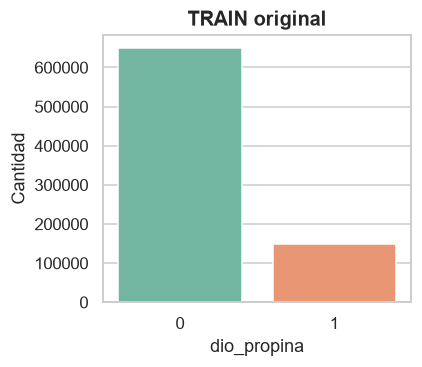

In [43]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Funciones tomadas de clase_05_desbalance.ipynb (catedra)
def plot_balance(y, titulo):
    fig, axes = plt.subplots(figsize=(4, 3.5))
    sns.countplot(x=y, hue=y, palette="Set2", ax=axes, legend=False)
    axes.set_xlabel(TARGET)
    axes.set_ylabel("Cantidad")
    axes.set_title(titulo)
    plt.tight_layout()
    plt.show()


def info(y, titulo="Distribucion"):
    print("Proporcion de clases:")
    print(y.value_counts(normalize=True).to_string())
    print("\nEntropia de Shannon:", round(shannon_entropy(pd.Series(y)), 4))
    plot_balance(y, titulo)


print(">>> TRAIN ORIGINAL (desbalanceado)")
info(y_train, "TRAIN original")

In [44]:
# --- Comparamos las dos tecnicas de la Clase 5 slide 27 -------------------
# Igual que en clase_05_desbalance.ipynb: SMOTE vs RandomUnderSampler.
# SMOTE sobre 800.000 filas es costoso: lo aplicamos sobre una submuestra
# para poder compararlo, y usamos undersampling para el pipeline final.
submuestra = 100_000
idx = X_train_escalado.sample(submuestra, random_state=SEMILLA).index

print("Aplicando SMOTE (oversampling) sobre una submuestra...")
smote = SMOTE(random_state=SEMILLA)
X_sm, y_sm = smote.fit_resample(X_train_escalado.loc[idx], y_train.loc[idx])

print("Aplicando RandomUnderSampler (undersampling) sobre TRAIN completo...")
undersample = RandomUnderSampler(random_state=SEMILLA)
X_train_balanceado, y_train_balanceado = undersample.fit_resample(X_train_escalado, y_train)

print()
print("COMPARACION DE TECNICAS")
print("=" * 64)
print(f"{'':<26}{'clase 0':>12}{'clase 1':>12}{'entropia':>12}")
print("-" * 64)
for nombre, serie in [("TRAIN original", y_train),
                      ("SMOTE (submuestra)", pd.Series(y_sm)),
                      ("Undersampling", pd.Series(y_train_balanceado))]:
    c = serie.value_counts()
    print(f"{nombre:<26}{c.get(0,0):>12,}{c.get(1,0):>12,}"
          f"{shannon_entropy(serie):>12.4f}")

Aplicando SMOTE (oversampling) sobre una submuestra...


  File "C:\Users\LEGION\OneDrive\FIUBA\CEIA\02.- ANALISIS DE DATOS\02.- TP\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\LEGION\OneDrive\FIUBA\CEIA\02.- ANALISIS DE DATOS\02.- TP\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\LEGION\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\LEGION\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\LEGION\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1538, in _execute_ch

Aplicando RandomUnderSampler (undersampling) sobre TRAIN completo...

COMPARACION DE TECNICAS
                               clase 0     clase 1    entropia
----------------------------------------------------------------
TRAIN original                 650,998     149,002      0.6936
SMOTE (submuestra)              81,318      81,318      1.0000
Undersampling                  149,002     149,002      1.0000


   figura guardada: figuras\09_balanceo_clases.png


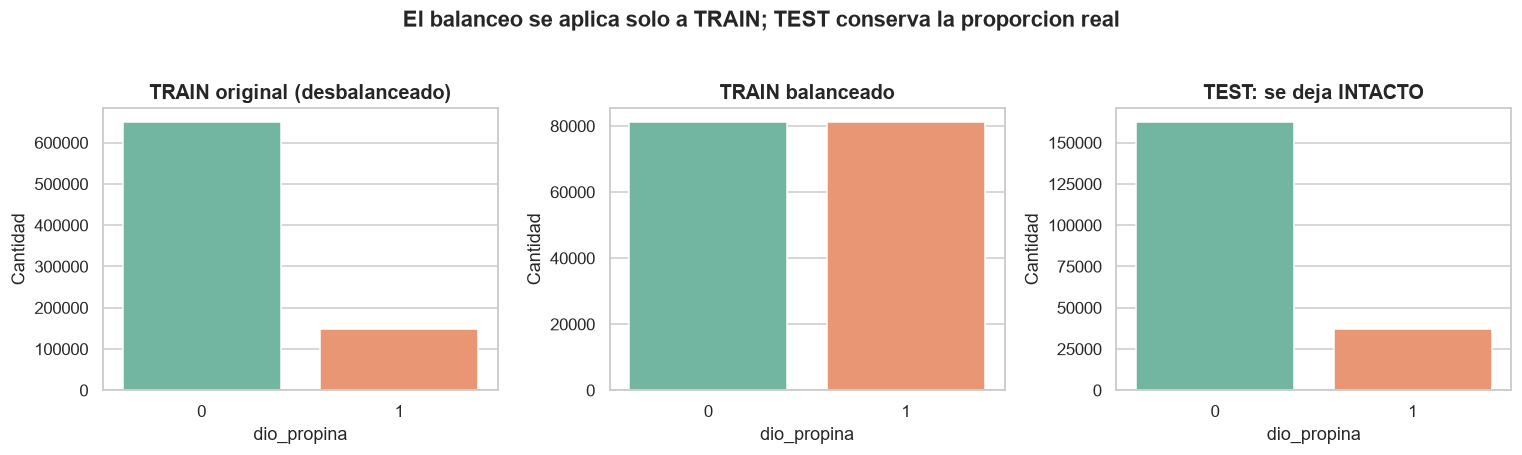

TEST sigue con la proporcion real:
   clase 1 (dejo propina): 18.62%


In [45]:
# Grafico de 3 paneles, como en clase_05_desbalance.ipynb
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.countplot(x=y_train, hue=y_train, palette="Set2", ax=axes[0], legend=False)
sns.countplot(x=y_sm, hue=y_sm, palette="Set2", ax=axes[1], legend=False)
sns.countplot(x=y_test, hue=y_test, palette="Set2", ax=axes[2], legend=False)

axes[0].set_title("TRAIN original (desbalanceado)")
axes[1].set_title("TRAIN balanceado")
axes[2].set_title("TEST: se deja INTACTO")

for i in (0, 1, 2):
    axes[i].set_xlabel("dio_propina")
    axes[i].set_ylabel("Cantidad")

plt.suptitle("El balanceo se aplica solo a TRAIN; TEST conserva la proporcion real",
             fontweight="bold", y=1.03)
plt.tight_layout()
guardar_figura("09_balanceo_clases")
plt.show()

print("TEST sigue con la proporcion real:")
print(f"   clase 1 (dejo propina): {y_test.mean()*100:.2f}%")

### Qué técnica elegimos y por qué

La Clase 5 slide 27 lista cuatro opciones: **oversampling** (ej. SMOTE), **undersampling**,
**weighted random sampler** y **técnicas de ensamble**. Probamos las dos primeras.

**Elegimos undersampling** para el pipeline final, por dos razones:

1. **Nos sobran datos.** Tenemos 800.000 filas de entrenamiento; descartar parte de la clase
   mayoritaria todavía nos deja casi 300.000. El principal defecto del undersampling
   —perder información— acá casi no pesa.
2. **No inventa datos.** SMOTE genera registros sintéticos que no existieron. Con este
   volumen no hace falta asumir ese riesgo.

Con un dataset chico la decisión sería la inversa: ahí SMOTE tendría más sentido, porque
descartar filas sería un lujo que no podríamos permitirnos.

---

# §17. Selección de features

> **Consigna:** *"Evaluar relaciones entre variables y realizar una selección de features
> con los mecanismos vistos en clase."*

La Clase 7 resume qué buscamos identificar *(Clase 7, slide 7)*:

| Buscamos | Cómo lo hacemos |
|---|---|
| features **irrelevantes o no disponibles** | Criterio y conocimiento del dominio |
| features **redundantes** | Medidas de asociación **entre features** |
| features con **relevancia predictiva** | Información mutua, tests de hipótesis |

## Las medidas de asociación según el par de tipos

La notebook `clase_06_seleccion_features.ipynb` define una medida distinta para cada
combinación de tipos de variable. Usamos sus funciones tal cual:

| Par de variables | Medida | Función de la cátedra |
|---|---|---|
| numérica – numérica | Pearson / Spearman | `.corr()` |
| categórica – categórica | **Cramér's V** | `cramers_v()` |
| binaria – binaria | **Coeficiente Phi** | `phi()` |
| numérica – categórica | **Eta cuadrado** | `eta_squared()` |
| numérica – binaria | **Punto biserial** | `pointbiserialr()` |

In [46]:
from scipy.stats import chi2_contingency, f_oneway, pointbiserialr

# --- Funciones de asociacion, tomadas de clase_06_seleccion_features.ipynb --

def phi(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    return np.sqrt(chi2 / n)


def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * min(k - 1, r - 1)))


def eta_squared(continuous, categorical):
    mask = continuous.notna() & categorical.notna()
    y_, grp = continuous[mask], categorical[mask]
    groups = [g.values for _, g in y_.groupby(grp, observed=True)]
    F, p = f_oneway(*groups)
    grand_mean = y_.mean()
    ss_total = ((y_ - grand_mean) ** 2).sum()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    return ss_between / ss_total, p, F


print("Funciones de asociacion definidas (Clase 6).")

Funciones de asociacion definidas (Clase 6).


   figura guardada: figuras\10_matriz_correlacion.png


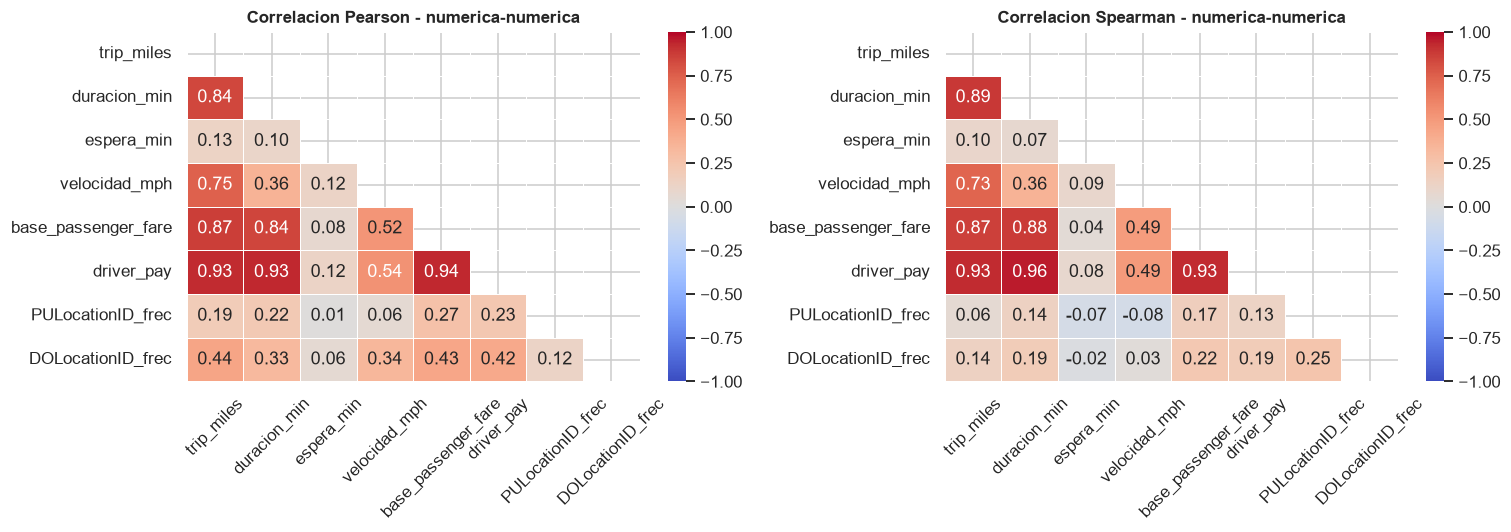

In [47]:
# --- 1) Numerica - numerica: Pearson y Spearman (Clase 6) -----------------
numericas_modelo = ["trip_miles", "duracion_min", "espera_min", "velocidad_mph",
                    "base_passenger_fare", "driver_pay",
                    "PULocationID_frec", "DOLocationID_frec"]

corr_pearson = X_train_escalado[numericas_modelo].corr(method="pearson")
corr_spearman = X_train_escalado[numericas_modelo].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, corr, title in zip(axes, [corr_pearson, corr_spearman], ["Pearson", "Spearman"]):
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
                vmin=-1, vmax=1, linewidths=0.5, center=0, mask=mask, ax=ax)
    ax.set_title(f"Correlacion {title} - numerica-numerica", fontsize=11)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
guardar_figura("10_matriz_correlacion")
plt.show()

   figura guardada: figuras\10b_cramers_v.png


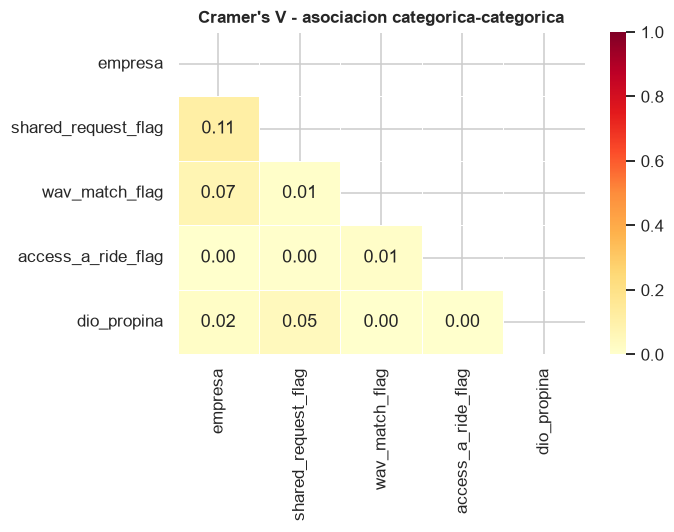

In [48]:
# --- 2) Categorica - categorica: Cramer's V (Clase 6) ---------------------
# Usamos las variables SIN codificar, guardadas antes del encoding
cat_cols = ["empresa", "shared_request_flag", "wav_match_flag", "access_a_ride_flag"]
datos_cat = X_train_original[cat_cols].copy()
datos_cat[TARGET] = y_train
cat_cols_con_target = cat_cols + [TARGET]

v_mat = pd.DataFrame(index=cat_cols_con_target, columns=cat_cols_con_target, dtype=float)
for c1 in cat_cols_con_target:
    for c2 in cat_cols_con_target:
        if c1 == c2:
            v_mat.loc[c1, c2] = 1.0
        else:
            mask = datos_cat[c1].notna() & datos_cat[c2].notna()
            v_mat.loc[c1, c2] = cramers_v(datos_cat.loc[mask, c1], datos_cat.loc[mask, c2])

mask = np.triu(np.ones_like(v_mat, dtype=bool))
fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(v_mat.astype(float), annot=True, fmt=".2f", cmap="YlOrRd",
            vmin=0, vmax=1, linewidths=0.5, mask=mask, ax=ax)
ax.set_title("Cramer's V - asociacion categorica-categorica", fontsize=11)
plt.tight_layout()
guardar_figura("10b_cramers_v")
plt.show()

   figura guardada: figuras\10c_eta_cuadrado.png


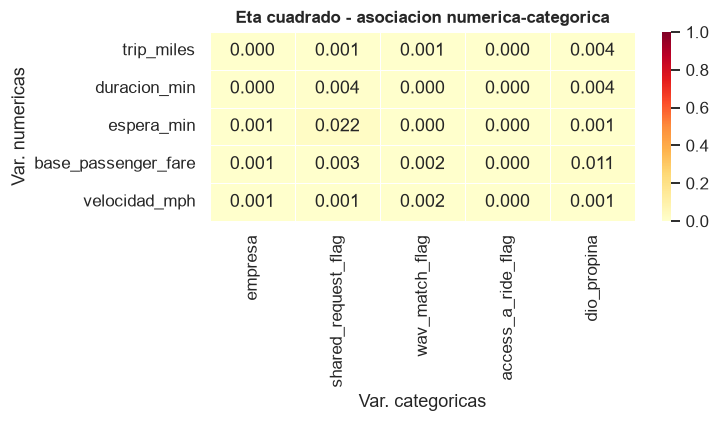

In [49]:
# --- 3) Numerica - categorica: Eta cuadrado (Clase 6) --------------------
num_cols_eta = ["trip_miles", "duracion_min", "espera_min",
                "base_passenger_fare", "velocidad_mph"]

resultados = {}
for num_col in num_cols_eta:
    for cat_col in cat_cols_con_target:
        eta2, p, F = eta_squared(X_train_original[num_col].reset_index(drop=True),
                                 datos_cat[cat_col].reset_index(drop=True))
        resultados[(num_col, cat_col)] = eta2

eta2_mat = pd.DataFrame(
    {cat: {num: resultados[(num, cat)] for num in num_cols_eta}
     for cat in cat_cols_con_target}
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(eta2_mat, annot=True, fmt=".3f", cmap="YlOrRd",
            vmin=0, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Eta cuadrado - asociacion numerica-categorica", fontsize=11)
ax.set_xlabel("Var. categoricas")
ax.set_ylabel("Var. numericas")
plt.tight_layout()
guardar_figura("10c_eta_cuadrado")
plt.show()

In [50]:
# Listamos los pares MUY correlacionados (candidatos a redundantes)
pares_correlacionados = []
matriz_correlacion = X_train_escalado.corr()

for i in range(len(matriz_correlacion.columns)):
    for j in range(i + 1, len(matriz_correlacion.columns)):
        correlacion = matriz_correlacion.iloc[i, j]
        if abs(correlacion) > 0.80:
            pares_correlacionados.append((matriz_correlacion.columns[i],
                                          matriz_correlacion.columns[j],
                                          correlacion))

print("PARES DE VARIABLES CON CORRELACION MAYOR A 0,80")
print("=" * 70)
for variable_a, variable_b, correlacion in sorted(pares_correlacionados,
                                                  key=lambda x: -abs(x[2])):
    print(f"   {variable_a:<24} <-> {variable_b:<24} {correlacion:>6.3f}")
print()
print("Estos pares son REDUNDANTES: aportan practicamente la misma informacion.")

PARES DE VARIABLES CON CORRELACION MAYOR A 0,80
   base_passenger_fare      <-> driver_pay                0.935
   driver_pay               <-> duracion_min              0.934
   trip_miles               <-> driver_pay                0.926
   trip_miles               <-> base_passenger_fare       0.868
   base_passenger_fare      <-> duracion_min              0.844
   trip_miles               <-> duracion_min              0.842

Estos pares son REDUNDANTES: aportan practicamente la misma informacion.


## Relevancia predictiva: ANOVA, Chi² e Información Mutua

La notebook `clase_06_seleccion_features.ipynb` usa **`SelectKBest`** con tres funciones de
score, y separa las variables numéricas de las categóricas:

- **ANOVA (`f_classif`)** para las numéricas contra la target categórica
- **Chi² (`chi2`)** para las categóricas contra la target categórica
- **Información Mutua (`mutual_info_classif`)** para todas, indicando con
  `discrete_features` si son discretas o continuas

Al final normaliza los tres resultados con `MinMaxScaler` y los compara en un heatmap.
Reproducimos ese procedimiento.

In [51]:
from sklearn.feature_selection import SelectKBest, f_classif, chi2, mutual_info_classif
from sklearn.preprocessing import MinMaxScaler

# Separamos numericas de categoricas/binarias, como hace la catedra
num_features = ["trip_miles", "duracion_min", "espera_min", "velocidad_mph",
                "base_passenger_fare", "driver_pay",
                "PULocationID_frec", "DOLocationID_frec",
                "hora_sen", "hora_cos", "dia_semana_sen", "dia_semana_cos"]
cat_features = ["shared_request_flag", "shared_match_flag", "access_a_ride_flag",
                "wav_request_flag", "wav_match_flag", "es_uber", "rango_distancia"]

# Para el analisis usamos el TRAIN balanceado, sin escalar en el caso de chi2
# (chi2 exige valores no negativos)
X_bal = pd.DataFrame(X_train_balanceado, columns=columnas_finales)
y_bal = pd.Series(y_train_balanceado)

X_bal_num = X_bal[num_features]
X_bal_cat = X_bal[cat_features]

# chi2 necesita valores >= 0: reescalamos las categoricas a [0, 1]
X_bal_cat_pos = pd.DataFrame(MinMaxScaler().fit_transform(X_bal_cat),
                             columns=cat_features)

# --- ANOVA sobre las numericas -------------------------------------------
selector_anova = SelectKBest(score_func=f_classif, k="all")
selector_anova.fit(X_bal_num, y_bal)
anova_scores = pd.Series(selector_anova.scores_, index=num_features, name="ANOVA_F")
anova_pvals = pd.Series(selector_anova.pvalues_, index=num_features, name="ANOVA_pval")

anova_result = pd.DataFrame({"score": anova_scores,
                             "p_value": anova_pvals}).sort_values("score", ascending=False)
print("ANOVA (numericas vs target categorica)")
print("=" * 55)
print(anova_result.to_string(float_format=lambda v: f"{v:,.4f}"))

ANOVA (numericas vs target categorica)
                         score  p_value
base_passenger_fare 5,581.4051   0.0000
driver_pay          3,076.6838   0.0000
PULocationID_frec   3,015.5716   0.0000
duracion_min        2,091.5839   0.0000
trip_miles          1,616.2447   0.0000
DOLocationID_frec   1,108.7277   0.0000
hora_cos              959.7570   0.0000
espera_min            627.0500   0.0000
velocidad_mph         217.0676   0.0000
dia_semana_sen        152.0165   0.0000
hora_sen              143.9549   0.0000
dia_semana_cos          9.8776   0.0017


In [52]:
# --- Chi2 sobre las categoricas ------------------------------------------
selector_chi2 = SelectKBest(score_func=chi2, k="all")
selector_chi2.fit(X_bal_cat_pos, y_bal)
chi2_scores = pd.Series(selector_chi2.scores_, index=cat_features, name="chi2")
chi2_pvals = pd.Series(selector_chi2.pvalues_, index=cat_features, name="chi2_pval")

chi2_result = pd.DataFrame({"score": chi2_scores,
                            "p_value": chi2_pvals}).sort_values("score", ascending=False)
print("CHI2 (categoricas vs target categorica)")
print("=" * 55)
print(chi2_result.to_string(float_format=lambda v: f"{v:,.4f}"))

CHI2 (categoricas vs target categorica)
                         score  p_value
shared_request_flag 1,310.4492   0.0000
shared_match_flag     806.7846   0.0000
rango_distancia       281.3266   0.0000
wav_request_flag       49.8037   0.0000
es_uber                49.0784   0.0000
access_a_ride_flag      5.8328   0.0157
wav_match_flag          3.8853   0.0487


In [53]:
# --- Informacion Mutua (Clase 6) -----------------------------------------
# La catedra la calcula por separado indicando si las features son discretas.
# Es costosa: usamos una submuestra, igual que hicimos con SMOTE.
TAMANO_MI = 50_000
idx_mi = X_bal.sample(min(TAMANO_MI, len(X_bal)), random_state=SEMILLA).index

mi_num = mutual_info_classif(X_bal_num.loc[idx_mi], y_bal.loc[idx_mi],
                             discrete_features=False, random_state=SEMILLA)
mi_num_series = pd.Series(mi_num, index=num_features, name="MI")

mi_cat = mutual_info_classif(X_bal_cat.loc[idx_mi], y_bal.loc[idx_mi],
                             discrete_features=True, random_state=SEMILLA)
mi_cat_series = pd.Series(mi_cat, index=cat_features, name="MI")

mi_all = pd.concat([mi_num_series, mi_cat_series])
mi_result = pd.DataFrame({"score": mi_all}).sort_values("score", ascending=False)

print("INFORMACION MUTUA (todas las features vs target)")
print("=" * 55)
# Los valores son chicos: mostramos 5 decimales para que se distingan
print(mi_result.to_string(float_format=lambda v: f"{v:.5f}"))

INFORMACION MUTUA (todas las features vs target)
                      score
PULocationID_frec   0.03884
DOLocationID_frec   0.03294
base_passenger_fare 0.01189
hora_cos            0.00457
trip_miles          0.00413
driver_pay          0.00388
velocidad_mph       0.00327
duracion_min        0.00248
dia_semana_cos      0.00210
rango_distancia     0.00201
shared_request_flag 0.00184
shared_match_flag   0.00109
es_uber             0.00036
wav_request_flag    0.00022
wav_match_flag      0.00003
access_a_ride_flag  0.00000
espera_min          0.00000
dia_semana_sen      0.00000
hora_sen            0.00000


   figura guardada: figuras\11_relevancia_features.png


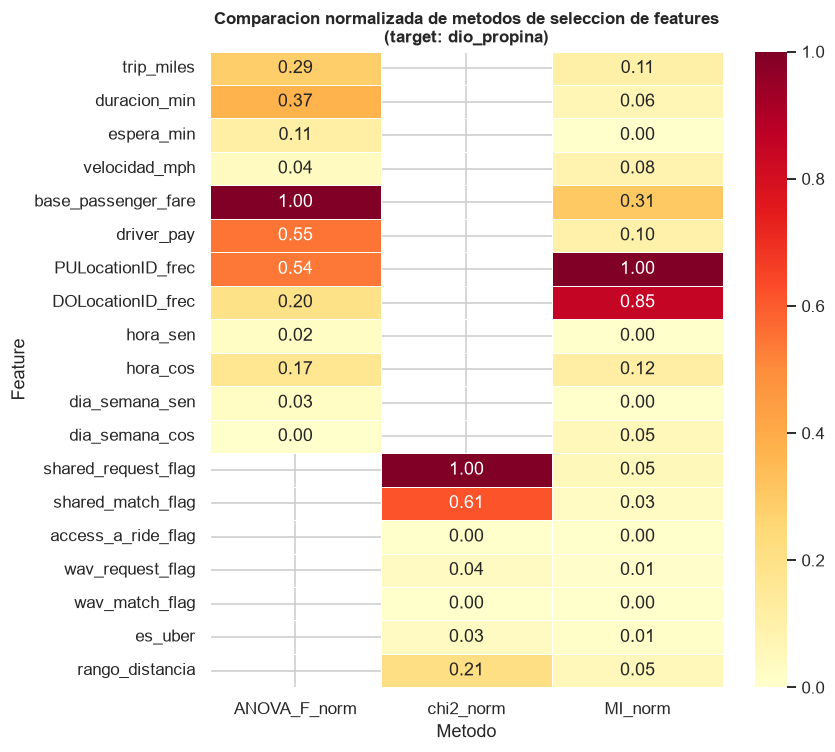

In [54]:
# --- Comparacion normalizada de los 3 metodos (Clase 6) ------------------
all_features = num_features + cat_features
comparison_df = pd.DataFrame(index=all_features)

comparison_df["ANOVA_F_norm"] = pd.Series(
    MinMaxScaler().fit_transform(anova_scores.values.reshape(-1, 1)).flatten(),
    index=num_features)

comparison_df["chi2_norm"] = pd.Series(
    MinMaxScaler().fit_transform(chi2_scores.values.reshape(-1, 1)).flatten(),
    index=cat_features)

comparison_df["MI_norm"] = pd.Series(
    MinMaxScaler().fit_transform(mi_all.values.reshape(-1, 1)).flatten(),
    index=mi_all.index)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(comparison_df.astype(float), annot=True, fmt=".2f", cmap="YlOrRd",
            vmin=0, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Comparacion normalizada de metodos de seleccion de features\n"
             "(target: dio_propina)", fontsize=11)
ax.set_xlabel("Metodo")
ax.set_ylabel("Feature")
plt.tight_layout()
guardar_figura("11_relevancia_features")
plt.show()

### Cómo se lee esto

- La **información mutua** mide cuánta información aporta una variable sobre la target. Si
  vale 0, la variable no dice nada sobre si el pasajero deja propina.
- El **test ANOVA (F)** compara las medias de cada variable numérica entre los dos grupos:
  un F alto con p-valor chico indica que la variable se comporta distinto según si hubo
  propina o no.
- **Chi²** hace lo análogo para las categóricas.

En el heatmap final, las celdas vacías corresponden a métodos que no aplican a ese tipo de
variable (ANOVA no se calcula sobre categóricas, Chi² no se calcula sobre numéricas). Ese es
el mismo formato que usa la notebook de la cátedra.

### ⚠️ ANOVA dice que todo es significativo, la Información Mutua dice que nada sirve

Comparando las dos tablas aparece algo que parece una contradicción:

- **ANOVA** da valores de F enormes (más de 5.500 para `base_passenger_fare`) con
  **p-valores de 0,0000** en todas las variables. Interpretado ingenuamente: "todas las
  variables son significativas".
- **La Información Mutua** dice que ninguna llega a 0,04.

**No hay contradicción: el p-valor está midiendo otra cosa.** Con 298.000 observaciones,
cualquier diferencia por mínima que sea se vuelve estadísticamente significativa. El
p-valor responde *"¿existe alguna diferencia?"*, no *"¿es una diferencia grande?"*.

La notebook `clase_06_seleccion_features.ipynb` plantea esta misma pregunta cuando analiza
el resultado de ANOVA para el Titanic: *"¿Es confiable este resultado de ANOVA?"*. La
lección es la misma: **significancia estadística no es lo mismo que relevancia práctica**,
y con muestras grandes la diferencia se agranda.

Por eso la Clase 6 no usa un solo método, sino tres, y los compara normalizados.

### ⚠️ Un resultado importante: la información mutua es baja en todas las variables

Los valores de información mutua son **muy chicos** — el más alto no llega a 0,05. Esto
significa que **ninguna de nuestras variables predice bien la propina**.

No es un error del análisis: es un hallazgo. Dejar propina parece depender de factores que
**no están en este dataset** — el trato del conductor, el estado de ánimo del pasajero, si
paga con tarjeta o efectivo. Las características del viaje (distancia, hora, zona) explican
muy poco.

Las dos variables que más aportan son las **frecuencias de zona** (`PULocationID_frec` y
`DOLocationID_frec`), lo que tiene sentido: la zona es un proxy del perfil socioeconómico
del pasajero, y eso sí se relaciona con la costumbre de dejar propina.

Es honesto decirlo: si entrenáramos un modelo con estos datos, probablemente tendría un
desempeño modesto. Y saberlo **antes** de entrenar es justamente para lo que sirve esta
etapa de análisis.

**El criterio de reducción**, que la Clase 7 slide 7 pide establecer explícitamente
(*"¿con cuántos y cuáles features nos queremos quedar?"*), es el siguiente:

1. **Descartamos por redundancia**: de cada par con correlación > 0,80 conservamos una sola
   variable. Como `base_passenger_fare`, `driver_pay`, `trip_miles` y `duracion_min` están
   todas correlacionadas entre sí por encima de 0,84, nos quedamos con `trip_miles` y
   `base_passenger_fare`.
2. **Descartamos por irrelevancia**: las features que quedan bajas en los **tres** métodos
   a la vez. Los flags de viaje compartido y accesibilidad caen en esta categoría, algo que
   ya anticipábamos en §5 por su baja entropía.

## Aplicamos la selección

Hasta acá **analizamos**. Ahora hay que **seleccionar de verdad**: la consigna pide
*"realizar una selección de features"*, no solo evaluarlas. Aplicamos los dos criterios.

In [55]:
# --- (a) REDUNDANCIA -------------------------------------------------------
# Ademas de Pearson miramos Spearman, porque rango_distancia es una version
# escalonada de trip_miles: Pearson las separa, pero Spearman las delata.
corr_sp = X_bal.corr(method="spearman").abs()
print("trip_miles vs rango_distancia:")
print(f"   Pearson : {X_bal[['trip_miles','rango_distancia']].corr().iloc[0,1]:.3f}")
print(f"   Spearman: {corr_sp.loc['trip_miles','rango_distancia']:.3f}   <-- es casi la misma variable")
print()

# Del bloque distancia/duracion/tarifa/pago conservamos DOS representantes:
# trip_miles (cuanto se viajo) y base_passenger_fare (cuanto se pago).
descartar_por_redundancia = ["driver_pay", "duracion_min", "rango_distancia"]
print("Descartadas por redundancia:", descartar_por_redundancia)

trip_miles vs rango_distancia:
   Pearson : 0.777
   Spearman: 0.968   <-- es casi la misma variable

Descartadas por redundancia: ['driver_pay', 'duracion_min', 'rango_distancia']


In [56]:
# --- (b) IRRELEVANCIA ------------------------------------------------------
# Descartamos las features con informacion mutua despreciable.
#
# OJO con las ciclicas: seno y coseno forman UN PAR. Quedarse con uno solo
# destruiria la codificacion, asi que el par se evalua y se descarta junto.
UMBRAL_MI = 0.001

pares_ciclicos = {
    "hora_sen": "hora_cos", "hora_cos": "hora_sen",
    "dia_semana_sen": "dia_semana_cos", "dia_semana_cos": "dia_semana_sen",
}

descartar_por_irrelevancia = []
for feature in columnas_finales:
    if feature in descartar_por_redundancia:
        continue
    mi = mi_all[feature]
    if feature in pares_ciclicos:                      # el par se evalua junto
        mi = max(mi, mi_all[pares_ciclicos[feature]])
    if mi < UMBRAL_MI:
        descartar_por_irrelevancia.append(feature)

print(f"Descartadas por irrelevancia (MI < {UMBRAL_MI}):")
for f in descartar_por_irrelevancia:
    print(f"   {f:<22} MI = {mi_all[f]:.5f}")

Descartadas por irrelevancia (MI < 0.001):
   access_a_ride_flag     MI = 0.00000
   wav_request_flag       MI = 0.00022
   wav_match_flag         MI = 0.00003
   espera_min             MI = 0.00000
   es_uber                MI = 0.00036


In [57]:
# --- Conjunto final de features -------------------------------------------
features_seleccionadas = [f for f in columnas_finales
                          if f not in descartar_por_redundancia
                          and f not in descartar_por_irrelevancia]

X_train_sel = X_bal[features_seleccionadas]
X_test_sel = X_test_escalado[features_seleccionadas]

print("SELECCION DE FEATURES - RESULTADO")
print("=" * 58)
print(f"   Features al empezar : {len(columnas_finales)}")
print(f"   Descartadas         : {len(descartar_por_redundancia) + len(descartar_por_irrelevancia)}")
print(f"   Features finales    : {len(features_seleccionadas)}")
print()
print("Conjunto final:")
for f in features_seleccionadas:
    print(f"   - {f:<22} MI = {mi_all[f]:.5f}")
print()
print(f"   X_train_sel: {X_train_sel.shape}")
print(f"   X_test_sel : {X_test_sel.shape}")

SELECCION DE FEATURES - RESULTADO
   Features al empezar : 19
   Descartadas         : 8
   Features finales    : 11

Conjunto final:
   - trip_miles             MI = 0.00413
   - base_passenger_fare    MI = 0.01189
   - shared_request_flag    MI = 0.00184
   - shared_match_flag      MI = 0.00109
   - velocidad_mph          MI = 0.00327
   - hora_sen               MI = 0.00000
   - hora_cos               MI = 0.00457
   - dia_semana_sen         MI = 0.00000
   - dia_semana_cos         MI = 0.00210
   - PULocationID_frec      MI = 0.03884
   - DOLocationID_frec      MI = 0.03294

   X_train_sel: (298004, 11)
   X_test_sel : (200000, 11)


### Dos observaciones sobre lo que acaba de pasar

**1. La discretización que hicimos en §14 terminó descartada.** `rango_distancia` es una
versión escalonada de `trip_miles`: la correlación de **Spearman entre las dos es 0,97**.
La consigna pedía aplicar discretización y la aplicamos, pero el propio análisis de
selección muestra que, teniendo la variable continua, la discretizada no aporta nada nuevo.

Es un resultado honesto: **hacer una transformación no obliga a conservarla**.

**2. Las variables cíclicas hay que evaluarlas de a pares.** `hora_sen` tiene información
mutua de 0,00000 y `hora_cos` de 0,00457. Si aplicáramos el umbral variable por variable,
descartaríamos el seno y nos quedaríamos con el coseno — y eso **rompería la codificación
cíclica**, porque las dos coordenadas juntas son las que ubican el punto en la
circunferencia. Una sola no representa nada.

Por eso el código evalúa el par con el máximo de los dos. Es un caso donde **aplicar el
criterio automáticamente, sin mirar qué significa cada variable, daría un resultado
equivocado**.

---

# §18. Reducción de dimensionalidad con PCA

> **Consigna:** *"Implementar la técnica de extracción de features vista en clase (PCA).
> Evaluar ventajas y desventajas de la reducción."*

## Qué hace PCA

La Clase 7 lo explica así: PCA *"transforma un conjunto de variables en un nuevo sistema de
referencia"* *(Clase 7, slide 12)*. Las direcciones nuevas —los **componentes
principales**— se ordenan de mayor a menor según cuánta varianza capturan.

## Diferencia con lo que hicimos en §17

- **Selección de features** (§17): elegimos un subconjunto de las variables originales. Las
  que quedan siguen siendo interpretables.
- **Extracción de features** (PCA, §18): creamos variables **nuevas** combinando las
  originales. Ganamos compresión pero perdemos interpretabilidad.

*(Clase 7, slide 6)*

## Primero, el cálculo artesanal

La notebook `clase_07_extraccion_features.ipynb` muestra el cálculo paso a paso con numpy
antes de usar sklearn, para que se vea qué hace por dentro. Lo reproducimos con nuestros
datos: matriz de covarianza → autovalores y autovectores → proyección.

In [58]:
# --- PCA ARTESANAL con numpy, como en clase_07_extraccion_features.ipynb ---
# Trabajamos sobre una submuestra chica para que se vea el procedimiento
X_artesanal = np.asarray(X_train_sel)[:5000]

# Paso 1: los datos ya estan estandarizados (seccion 15), asi que solo centramos
mean_vec = np.mean(X_artesanal, axis=0)
Xc = X_artesanal - mean_vec

# Paso 2: matriz de covarianza
cov_matrix = np.cov(Xc, rowvar=False)
print("Matriz de covarianza:", cov_matrix.shape)

# Paso 3: autovalores y autovectores
eigvals, eigvecs = np.linalg.eigh(cov_matrix)

# Los ordenamos de mayor a menor segun el autovalor
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

print("\nPrimeros 5 autovalores:", np.round(eigvals[:5], 4))

# Paso 4: varianza explicada
explained_variance_ratio = eigvals / np.sum(eigvals)
print("\nVarianza explicada por los primeros 5 (%):",
      np.round(explained_variance_ratio[:5] * 100, 2))

# Paso 5: proyeccion sobre los 2 primeros componentes
W = eigvecs[:, :2]
Y_proyectado = Xc @ W
print("\nDatos proyectados (primeras 3 filas):")
print(np.round(Y_proyectado[:3], 3))

Matriz de covarianza: (11, 11)

Primeros 5 autovalores: [2.5939 1.8046 1.188  1.0661 1.0065]

Varianza explicada por los primeros 5 (%): [24.31 16.91 11.13  9.99  9.43]

Datos proyectados (primeras 3 filas):
[[-0.694 -0.389]
 [ 1.355 -0.056]
 [ 1.564 -0.174]]


## Ahora con sklearn

La Clase 7 advierte que `PCA` de sklearn *"por defecto centra los datos, pero no los
escala"* — por eso la estandarización de §15 era imprescindible *(Clase 7, slide 10)*.

In [59]:
from sklearn.decomposition import PCA

# PCA se AJUSTA sobre TRAIN y se APLICA a los dos conjuntos
pca = PCA(random_state=SEMILLA)
pca.fit(X_train_sel)                        # <-- fit: solo TRAIN, features SELECCIONADAS

varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

print("VARIANZA EXPLICADA POR CADA COMPONENTE PRINCIPAL")
print("=" * 62)
print(f"{'componente':<14}{'autovalor':>13}{'% varianza':>14}{'% acumulado':>15}")
print("-" * 62)
for i in range(len(varianza_explicada)):
    print(f"PC{i+1:<12}{pca.explained_variance_[i]:>13.4f}"
          f"{100*varianza_explicada[i]:>13.2f}%{100*varianza_acumulada[i]:>14.2f}%")

VARIANZA EXPLICADA POR CADA COMPONENTE PRINCIPAL
componente        autovalor    % varianza    % acumulado
--------------------------------------------------------------
PC1                  3.1907        28.77%         28.77%
PC2                  1.4286        12.88%         41.65%
PC3                  1.2206        11.01%         52.65%
PC4                  1.0795         9.73%         62.39%
PC5                  1.0060         9.07%         71.46%
PC6                  0.9584         8.64%         80.10%
PC7                  0.8805         7.94%         88.04%
PC8                  0.7029         6.34%         94.37%
PC9                  0.3673         3.31%         97.69%
PC10                 0.1771         1.60%         99.28%
PC11                 0.0795         0.72%        100.00%


   figura guardada: figuras\12_pca_scree_varianza.png


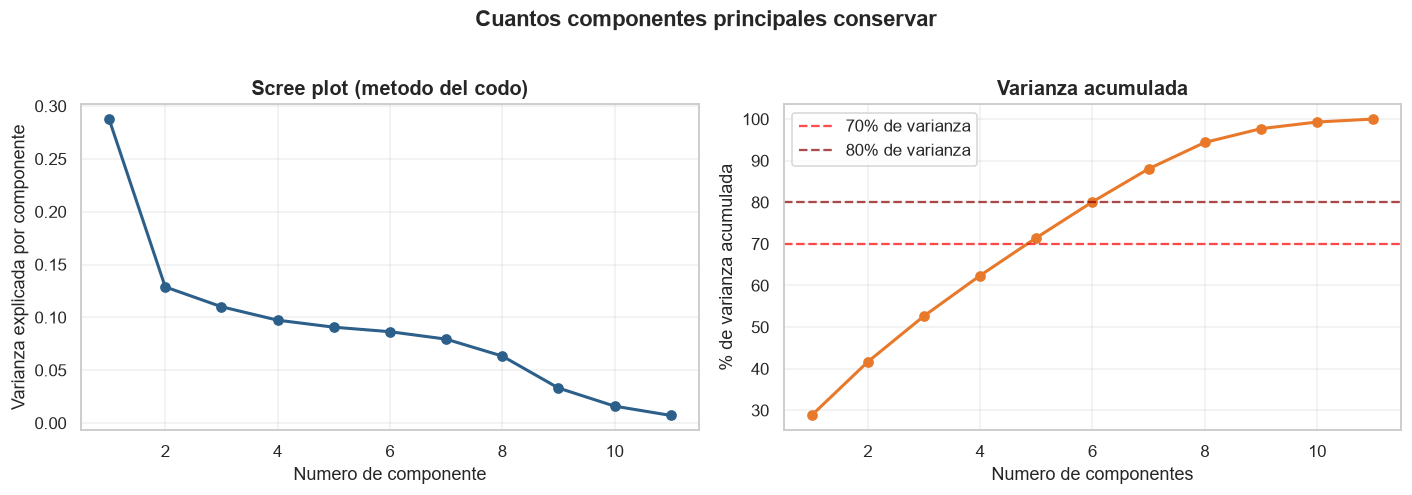

Para retener el 70% de la varianza hacen falta 5 componentes.
Para retener el 80% de la varianza hacen falta 6 componentes.
Variables que entran a PCA: 11


In [60]:
# --- Cuantos componentes elegir ------------------------------------------
# Clase 7, slide 22: dos criterios.
#   (a) el metodo del codo
#   (b) quedarse con los que acumulen entre 70% y 80% de la varianza
k_70 = int(np.argmax(varianza_acumulada >= 0.70) + 1)
k_80 = int(np.argmax(varianza_acumulada >= 0.80) + 1)

fig, ejes = plt.subplots(1, 2, figsize=(13, 4.4))

ejes[0].plot(range(1, len(varianza_explicada) + 1), varianza_explicada,
             marker="o", color=AZUL, linewidth=2)
ejes[0].set_title("Scree plot (metodo del codo)")
ejes[0].set_xlabel("Numero de componente")
ejes[0].set_ylabel("Varianza explicada por componente")
ejes[0].grid(True, alpha=0.3)

ejes[1].plot(range(1, len(varianza_acumulada) + 1), 100 * varianza_acumulada,
             marker="o", color=NARANJA, linewidth=2)
ejes[1].axhline(70, color="red", linestyle="--", alpha=0.7, label="70% de varianza")
ejes[1].axhline(80, color="darkred", linestyle="--", alpha=0.7, label="80% de varianza")
ejes[1].set_title("Varianza acumulada")
ejes[1].set_xlabel("Numero de componentes")
ejes[1].set_ylabel("% de varianza acumulada")
ejes[1].legend()
ejes[1].grid(True, alpha=0.3)

plt.suptitle("Cuantos componentes principales conservar", fontweight="bold", y=1.02)
plt.tight_layout()
guardar_figura("12_pca_scree_varianza")
plt.show()

print(f"Para retener el 70% de la varianza hacen falta {k_70} componentes.")
print(f"Para retener el 80% de la varianza hacen falta {k_80} componentes.")
print(f"Variables que entran a PCA: {X_train_sel.shape[1]}")

In [61]:
# --- Aplicamos PCA con el k elegido --------------------------------------
K_ELEGIDO = k_80   # criterio de la Clase 7 slide 22: 70-80% de varianza

pca_final = PCA(n_components=K_ELEGIDO, random_state=SEMILLA)
pca_final.fit(X_train_sel)                               # <-- fit: solo TRAIN

X_train_scores = pca_final.transform(X_train_sel)        # scores (Clase 7)
X_test_scores = pca_final.transform(X_test_sel)

print("RESULTADO DE LA REDUCCION")
print("=" * 55)
print(f"   Dimensiones antes : {X_train_sel.shape[1]}")
print(f"   Dimensiones ahora : {X_train_scores.shape[1]}")
print(f"   Reduccion         : {100*(1 - K_ELEGIDO/X_train_sel.shape[1]):.1f}%")
print(f"   Varianza retenida : {100*varianza_acumulada[K_ELEGIDO-1]:.2f}%")
print()
print(f"   TRAIN transformado: {X_train_scores.shape}")
print(f"   TEST  transformado: {X_test_scores.shape}")

RESULTADO DE LA REDUCCION
   Dimensiones antes : 11
   Dimensiones ahora : 6
   Reduccion         : 45.5%
   Varianza retenida : 80.10%

   TRAIN transformado: (298004, 6)
   TEST  transformado: (200000, 6)


   figura guardada: figuras\13_pca_loadings.png


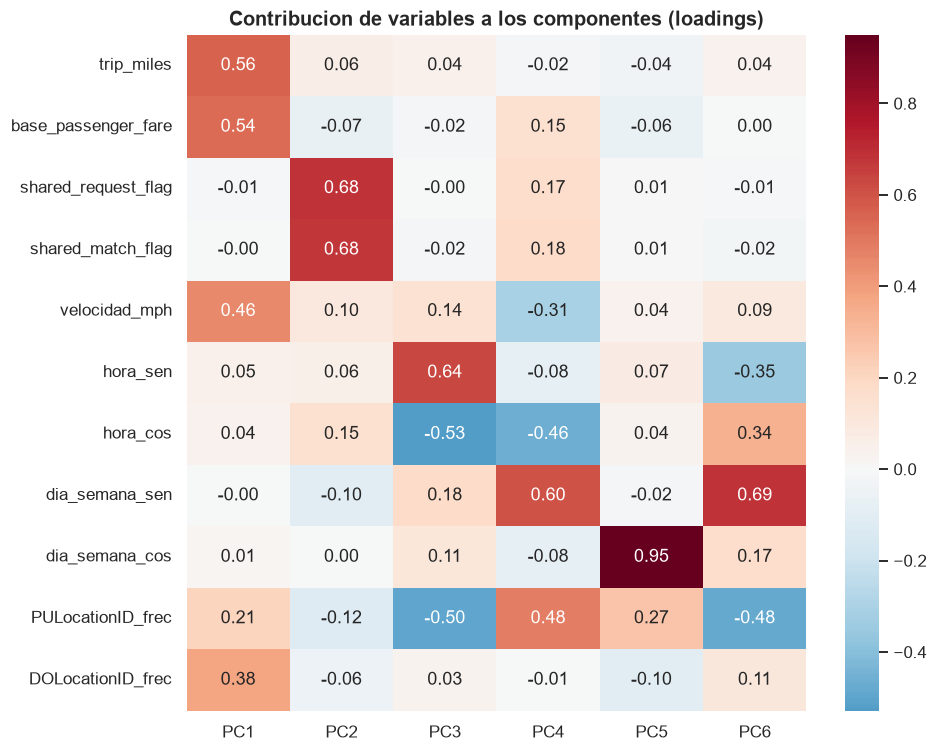

In [62]:
# --- Loadings: cuanto contribuye cada variable a cada componente ----------
# Clase 7 slide 12: los loadings "muestran cuanto contribuye cada variable
# a esa direccion". Formato de clase_07_extraccion_features.ipynb.
loadings = pd.DataFrame(
    pca_final.components_.T,
    columns=[f"PC{i+1}" for i in range(K_ELEGIDO)],
    index=features_seleccionadas,
)

plt.figure(figsize=(9, 7))
sns.heatmap(loadings.iloc[:, :6], annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Contribucion de variables a los componentes (loadings)")
plt.tight_layout()
guardar_figura("13_pca_loadings")
plt.show()

   figura guardada: figuras\14_pca_contribuciones.png


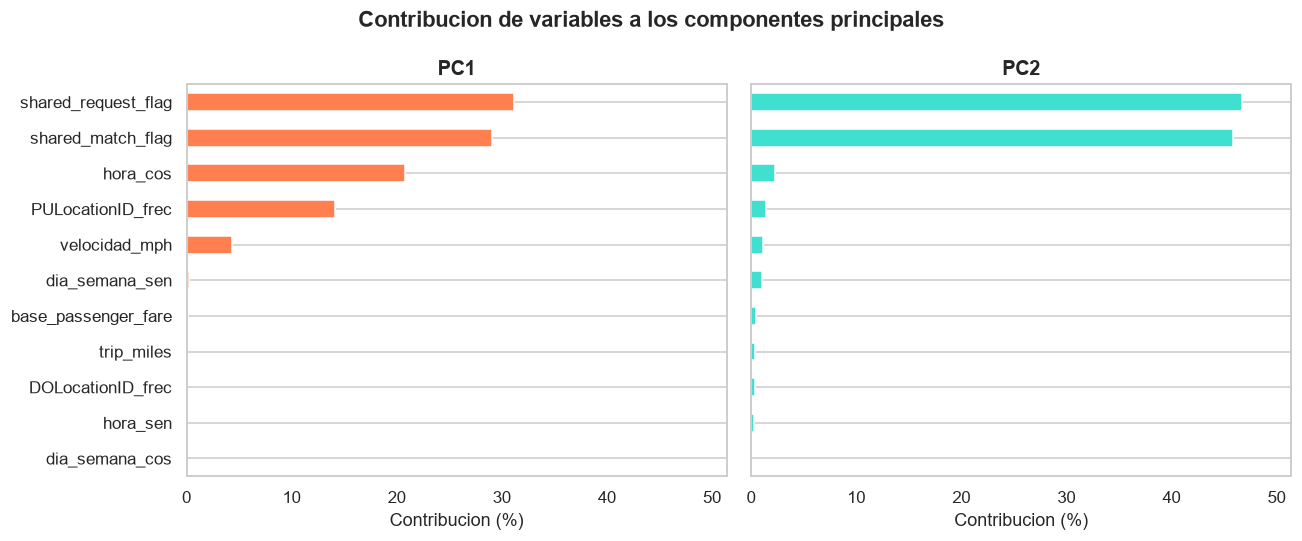

Variables que mas pesan en PC1:
trip_miles            31.17
base_passenger_fare   29.03
velocidad_mph         20.83
DOLocationID_frec     14.17
PULocationID_frec      4.36


In [63]:
# --- Contribuciones porcentuales por componente (Clase 7) ----------------
contrib = (loadings ** 2)
contrib = contrib.div(contrib.sum(axis=0), axis=1) * 100

fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

contrib["PC1"].sort_values().plot.barh(ax=ax[0], color="coral")
ax[0].set_title("PC1")
ax[0].set_xlabel("Contribucion (%)")
ax[0].grid(axis="x")

contrib["PC2"].sort_values().plot.barh(ax=ax[1], color="turquoise")
ax[1].set_title("PC2")
ax[1].set_xlabel("Contribucion (%)")
ax[1].grid(axis="x")

max_val = contrib[["PC1", "PC2"]].max().max()
ax[0].set_xlim(0, max_val * 1.1)
ax[1].set_xlim(0, max_val * 1.1)

plt.suptitle("Contribucion de variables a los componentes principales", fontweight="bold")
plt.tight_layout()
guardar_figura("14_pca_contribuciones")
plt.show()

print("Variables que mas pesan en PC1:")
print(contrib["PC1"].sort_values(ascending=False).head(5).round(2).to_string())

   figura guardada: figuras\15_pca_biplot.png


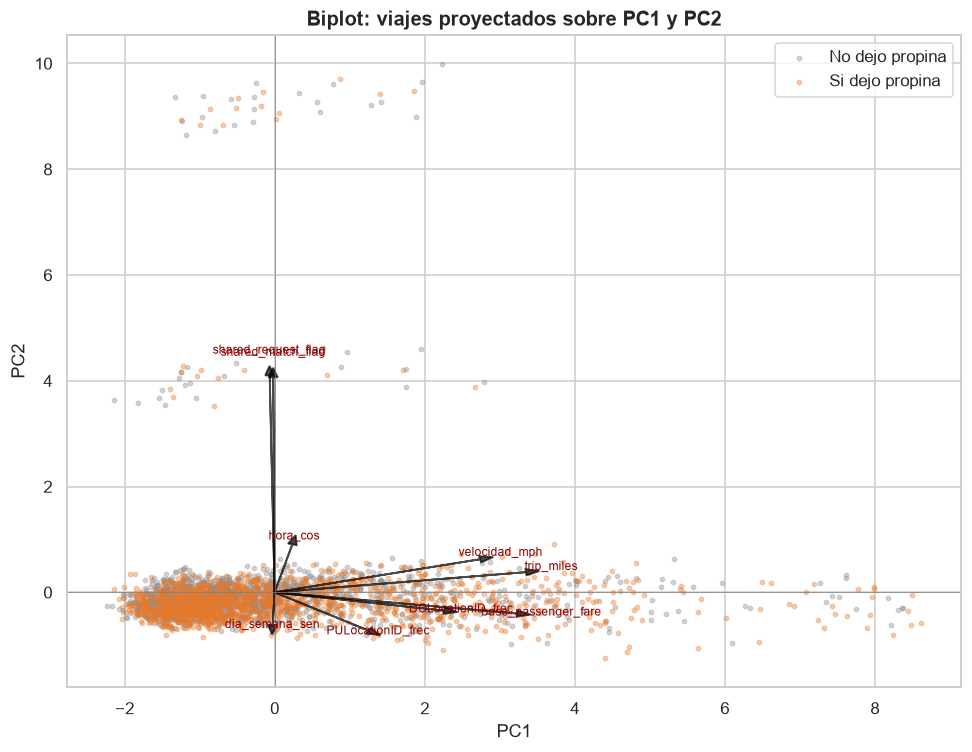

In [64]:
# --- Biplot: los datos proyectados mas las flechas de las variables -------
# Funcion adaptada de plot_biplot() en clase_07_extraccion_features.ipynb
def plot_biplot(scores, loadings, feature_names, target=None, muestra=3000):
    plt.figure(figsize=(9, 7))

    n = min(muestra, len(scores))
    idx_plot = np.random.RandomState(SEMILLA).choice(len(scores), n, replace=False)

    if target is None:
        plt.scatter(scores[idx_plot, 0], scores[idx_plot, 1], alpha=0.3, s=8, color=AZUL)
    else:
        t = np.asarray(target)[idx_plot]
        for valor, color, etiqueta in [(0, GRIS, "No dejo propina"),
                                       (1, NARANJA, "Si dejo propina")]:
            sel = t == valor
            plt.scatter(scores[idx_plot][sel, 0], scores[idx_plot][sel, 1],
                        alpha=0.35, s=8, color=color, label=etiqueta)
        plt.legend()

    # Flechas: una por variable, en la direccion de su loading
    escala = 6
    for i, feature in enumerate(feature_names):
        x_flecha = loadings.iloc[i, 0] * escala
        y_flecha = loadings.iloc[i, 1] * escala
        if abs(x_flecha) < 0.6 and abs(y_flecha) < 0.6:
            continue   # no dibujamos las flechas muy chicas, para no tapar
        plt.arrow(0, 0, x_flecha, y_flecha, color="black",
                  alpha=0.7, head_width=0.12, linewidth=1.2)
        plt.text(x_flecha * 1.1, y_flecha * 1.1, feature,
                 color="darkred", fontsize=8, ha="center")

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("Biplot: viajes proyectados sobre PC1 y PC2")
    plt.axhline(0, color="gray", linewidth=0.5)
    plt.axvline(0, color="gray", linewidth=0.5)
    plt.tight_layout()


plot_biplot(X_train_scores, loadings, features_seleccionadas, target=y_train_balanceado)
guardar_figura("15_pca_biplot")
plt.show()

### Ventajas y desventajas de la reducción

> **Consigna:** *"Evaluar ventajas y desventajas de la reducción."*

La Clase 7 slide 25 las enumera, y las verificamos en nuestro caso:

**Ventajas**

- **Menos dimensiones**, reteniendo alrededor del 80 % de la varianza.
- **Se elimina la redundancia.** Los componentes principales son ortogonales entre sí, o
  sea que por construcción no están correlacionados. Esto resuelve de raíz los pares
  redundantes que detectamos en §17.
- **Menor costo computacional.** Es lo que la Clase 6 slide 8 señala sobre la maldición de
  la dimensionalidad: *"el costo computacional aumenta exponencialmente"* con las
  dimensiones.

**Desventajas** *(Clase 7, slide 25)*

- ***"Al reducir dimensiones se pierde información."***
- ***"Técnicas como PCA transforman los features originales y después cuesta
  interpretarlos."*** Ésta es la desventaja más seria acá: "PC1" no significa nada para
  nadie.
- **PCA asume relaciones lineales** *(Clase 7, slide 12)*.

### Un resultado que conviene mirar de cerca

**PCA comprimió menos de lo esperable.** El primer componente explica apenas el **28,8 %**
de la varianza, y hacen falta **6 de los 11** componentes para llegar al 80 %. En un dataset
donde PCA funciona bien, los primeros dos o tres suelen concentrar la mayor parte.

¿Por qué pasa esto? Porque después de la codificación (§14) y de la selección (§17), buena
parte de las variables que quedan son **casi independientes entre sí**: los senos y cosenos
de la hora y el día, los flags de viaje compartido y las frecuencias de zona no comparten
información. **PCA solo puede comprimir lo que está correlacionado**, y en §17 justamente
descartamos las variables redundantes — es decir que le sacamos a PCA la mayor parte de lo que
podía comprimir.

Lo que le quedó es el bloque de distancia, tarifa y velocidad, y eso es exactamente lo que
absorbe PC1: `trip_miles` (31 %), `base_passenger_fare` (29 %) y `velocidad_mph` (21 %)
concentran el 81 % de su contribución. Se ve en el gráfico de contribuciones y en el biplot:
las flechas largas son todas de ese bloque.

> 📌 **Esto ilustra algo que vale la pena decir en la defensa:** selección y extracción de
> features **compiten**. Si primero se descartan las variables redundantes, PCA queda con
> poco margen. Aplicar las dos técnicas en cadena no multiplica el beneficio.

**En el biplot también se ve otra cosa importante:** las nubes de puntos de las dos clases
(dejó propina / no dejó) están **muy superpuestas** sobre PC1 y PC2. Eso indica que las dos
primeras direcciones de máxima varianza **no son las que separan la target**. Es un
recordatorio de que PCA es una técnica **no supervisada**: busca varianza, no capacidad de
discriminar entre clases.

**Nuestra conclusión:** para este problema en particular, **la interpretabilidad vale más
que la compresión**. El objetivo del análisis es *entender* qué hace que un pasajero deje
propina, y con componentes principales esa explicación se pierde. PCA quedaría justificado
si el objetivo fuera puramente predictivo o si tuviéramos cientos de variables — que no es
el caso.

---

# §19. El flujo completo: datasets listos para entrenar

> **Enunciado:** *"...hacer el EDA completo y realizar **la preparación del set de datos
> para el entrenamiento** del modelo de ML planteado."*

Todo lo que hicimos desde §10 sigue el **flujo de preparación de datos** de la cátedra,
que se arma progresivamente en la Clase 5 *(slide 37)* y se completa en la Clase 7
*(slides 5 y 26)* con la reducción de dimensionalidad.

La cátedra tiene además una notebook que hace este recorrido de punta a punta:
`recursos/taller_clasificacion.ipynb`, titulada *"Taller práctico — preparación completa de
un dataset para entrenamiento de modelos de IA"*. Es el modelo que seguimos.

## El flujo, y dónde lo cubrimos

```
                    ┌─────────────────────────────────────────────┐
   Split del   ───► │      Calcular y aplicar transformaciones     │
    dataset         └─────────────────────────────────────────────┘
                                    │
        ┌───────────────────────────┴───────────────────────────┐
        ▼                                                       ▼
   TRAIN dataset                                          TEST dataset
   CALCULAR Y APLICAR                                     solo APLICAR
        │                                                       │
   Tratar nulos                                           Tratar nulos
   Tratar outliers                                        Tratar outliers
   Crear features                                         Crear features
   Discretizar                                            Discretizar
   Codificar                                              Codificar
   Escalar                                                Escalar
   Balancear                                              ✗ Balancear   (NO)
   Reducir dimensionalidad                                Reducir dimensionalidad
        │                                                       │
        ▼                                                       ▼
   TRAIN transformado ──► Entrenar         TEST transformado ──► Evaluar
```

| Paso del flujo | Sección | Estado |
|---|---|---|
| **Split del dataset** | §11 | ✅ estratificado 80/20 |
| Tratar nulos | §12 | ✅ `fit` en TRAIN, `transform` en ambos |
| Tratar outliers | §13 | ✅ límites calculados en TRAIN |
| Crear features | §3 | ⚠️ **antes del split** — se explica abajo |
| Discretizar | §14 | ✅ puntos de corte de TRAIN |
| Codificar | §14 | ✅ frecuencias de TRAIN |
| Escalar | §15 | ✅ `fit` en TRAIN |
| Balancear | §16 | ✅ **solo TRAIN**; TEST intacto |
| Reducir dimensionalidad | §17–§18 | ✅ selección + PCA, `fit` en TRAIN |
| **TRAIN / TEST transformado** | **§19** | ⬅️ *lo hacemos ahora* |
| Entrenar / evaluar modelo | — | ❌ **fuera de la consigna** |

## El desvío: los features se crearon antes del split

En el diagrama, *"Crear features"* va **después** del split; nosotros lo hicimos en §3 sobre
el dataset completo. **No es un descuido, y conviene entender por qué no genera fuga.**

Hay dos clases de transformaciones:

| Tipo | Ejemplo nuestro | ¿Puede ir antes del split? |
|---|---|---|
| **Fila por fila**, no aprende nada del conjunto | `duracion_min = trip_time / 60`<br>`hora = pickup.dt.hour`<br>`velocidad = millas / horas` | **Sí.** El resultado de una fila no depende de las otras |
| **Aprende un parámetro** del conjunto | mediana de imputación, percentil 99 de recorte, frecuencia de cada zona, media y desvío del escalado, componentes de PCA | **No.** Acá sí habría contaminación |

Nuestras seis variables derivadas son todas del primer tipo. La Clase 5 slide 9 las llama
*"matemáticas (A/B, A−B)"* y *"temporales: extraer día, hora, mes de un timestamp"* — que es
exactamente lo que son.

Todo lo del segundo tipo se hizo **después** del split y **siempre ajustando sobre TRAIN**.

> 📌 **La regla corta:** lo que se calcula mirando **otras filas** va después del split. Lo
> que se calcula mirando **solo esa fila** puede ir antes.

## Una decisión que vale la pena declarar: el split es aleatorio, no temporal

La Clase 4 slide 10 menciona un caso especial: en **series temporales** hay que *"separar por
fecha sin mezclar pasado y futuro"*.

Nuestros datos tienen dimensión temporal —son todos los viajes de un mes— pero **no son una
serie temporal**: cada viaje es un evento independiente, y la target (dejar propina) es una
decisión del pasajero, no una magnitud que evolucione en el tiempo. Por eso el split
aleatorio estratificado es adecuado.

**Cuándo habría que cambiarlo:** si el objetivo fuera predecir la demanda futura, o si
sospecháramos un cambio de comportamiento a lo largo del mes. En ese caso correspondería
entrenar con las primeras semanas y evaluar con la última.

In [65]:
# ===================== TRAIN Y TEST TRANSFORMADOS =====================
# Los dos datasets que cierran el flujo, con la target incluida.

# --- Version A: features seleccionadas (interpretables) -------------------
train_preparado = X_train_sel.copy()
train_preparado[TARGET] = np.asarray(y_train_balanceado)

test_preparado = X_test_sel.copy()
test_preparado[TARGET] = y_test.values

# --- Version B: componentes principales (flujo hasta el final) ------------
columnas_pc = [f"PC{i+1}" for i in range(K_ELEGIDO)]

train_pca = pd.DataFrame(X_train_scores, columns=columnas_pc)
train_pca[TARGET] = np.asarray(y_train_balanceado)

test_pca = pd.DataFrame(X_test_scores, columns=columnas_pc)
test_pca[TARGET] = y_test.values

print("DATASETS FINALES")
print("=" * 64)
print(f"{'':<28}{'filas':>12}{'columnas':>11}{'% clase 1':>12}")
print("-" * 64)
for nombre, d in [("TRAIN preparado (11 feat)", train_preparado),
                  ("TEST  preparado (11 feat)", test_preparado),
                  ("TRAIN PCA (6 componentes)", train_pca),
                  ("TEST  PCA (6 componentes)", test_pca)]:
    print(f"{nombre:<28}{len(d):>12,}{d.shape[1]:>11}{100*d[TARGET].mean():>11.2f}%")

DATASETS FINALES
                                   filas   columnas   % clase 1
----------------------------------------------------------------
TRAIN preparado (11 feat)        298,004         12      50.00%
TEST  preparado (11 feat)        200,000         12      18.62%
TRAIN PCA (6 componentes)        298,004          7      50.00%
TEST  PCA (6 componentes)        200,000          7      18.62%


In [66]:
# Control de integridad antes de dar por cerrada la preparacion
print("CONTROL DE INTEGRIDAD")
print("=" * 60)
print(f"   TRAIN balanceado -> clase 1: {100*train_preparado[TARGET].mean():5.2f}%   (esperado ~50%)")
print(f"   TEST  sin tocar  -> clase 1: {100*test_preparado[TARGET].mean():5.2f}%   (esperado ~18,6%)")
print()
print(f"   Faltantes en TRAIN: {train_preparado.isna().sum().sum()}")
print(f"   Faltantes en TEST : {test_preparado.isna().sum().sum()}")
print()
mismas = list(train_preparado.columns) == list(test_preparado.columns)
print(f"   TRAIN y TEST tienen las mismas columnas: {mismas}")
print(f"   'tips' NO esta entre los features: {'tips' not in train_preparado.columns}")
print()
print("Primeras filas de TRAIN preparado:")
train_preparado.head(3)

CONTROL DE INTEGRIDAD
   TRAIN balanceado -> clase 1: 50.00%   (esperado ~50%)
   TEST  sin tocar  -> clase 1: 18.62%   (esperado ~18,6%)

   Faltantes en TRAIN: 0
   Faltantes en TEST : 0

   TRAIN y TEST tienen las mismas columnas: True
   'tips' NO esta entre los features: True

Primeras filas de TRAIN preparado:


,trip_miles,base_passenger_fare,shared_request_flag,shared_match_flag,velocidad_mph,hora_sen,hora_cos,dia_semana_sen,dia_semana_cos,PULocationID_frec,DOLocationID_frec,dio_propina
17518581,0.38,0.55,-0.17,-0.13,-0.04,0.26,-1.32,-0.45,-1.22,-1.04,1.34,0
19159127,-0.71,-0.60,-0.17,-0.13,-0.82,-1.00,0.82,-0.94,1.00,-0.48,-0.66,0
18363395,-0.88,-0.86,-0.17,-0.13,-0.87,-1.15,-0.26,-1.21,-0.23,-0.30,-0.28,0


In [67]:
# Guardamos los datasets, listos para un futuro entrenamiento.
# NO se versionan en el repositorio: son datos derivados y se regeneran
# ejecutando este notebook.
CARPETA_SALIDA = Path("datos_preparados")
CARPETA_SALIDA.mkdir(exist_ok=True)

archivos = {
    "train_preparado.parquet": train_preparado,
    "test_preparado.parquet": test_preparado,
    "train_pca.parquet": train_pca,
    "test_pca.parquet": test_pca,
}

print("ARCHIVOS GUARDADOS")
print("=" * 56)
for nombre, datos in archivos.items():
    ruta = CARPETA_SALIDA / nombre
    datos.to_parquet(ruta, index=False)
    print(f"   {nombre:<28} {ruta.stat().st_size/1e6:>6.1f} MB")

ARCHIVOS GUARDADOS
   train_preparado.parquet         5.0 MB


   test_preparado.parquet          3.4 MB
   train_pca.parquet              15.9 MB


   test_pca.parquet               11.3 MB


## Cuál de las dos versiones usar

Guardamos **dos**, porque sirven para objetivos distintos:

| Versión | Qué contiene | Cuándo conviene |
|---|---|---|
| `train_preparado` / `test_preparado` | Las **11 features seleccionadas** | **Recomendada.** Las variables conservan su significado: se puede explicar qué influye |
| `train_pca` / `test_pca` | Los **6 componentes principales** | Si el objetivo fuera solo predecir, sin necesidad de interpretar |

Es coherente con la conclusión de §18: acá **la interpretabilidad vale más que la
compresión**, y además la reducción que aportó PCA fue modesta.

## Qué vendría después (fuera del alcance de este trabajo)

> ⚠️ El enunciado dice que **el entrenamiento no es requerido y agregarlo no impacta en la
> nota**. Lo mostramos solo para dejar claro que los datasets quedan en el formato correcto
> para el paso siguiente.

```python
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

train = pd.read_parquet("datos_preparados/train_preparado.parquet")
test  = pd.read_parquet("datos_preparados/test_preparado.parquet")

X_tr, y_tr = train.drop(columns="dio_propina"), train["dio_propina"]
X_te, y_te = test.drop(columns="dio_propina"),  test["dio_propina"]

modelo = RandomForestClassifier(random_state=42).fit(X_tr, y_tr)
print(classification_report(y_te, modelo.predict(X_te)))
```

**Tres cosas que suelen salir mal ya están resueltas** en esos archivos:

1. El **split está hecho**, y todas las transformaciones se ajustaron solo sobre TRAIN.
2. TRAIN está **balanceado** y TEST conserva la **proporción real**, así que las métricas
   van a ser honestas y no infladas.
3. **No hay fuga de datos**: `tips`, de donde sale la target, se descartó en §10.

Y una advertencia para quien lo entrene: por lo que vimos en §17, **la información mutua de
todas las features es baja**. Es razonable esperar un desempeño modesto. Eso no es un
problema de la preparación — es lo que estos datos pueden dar.

---

# §20. Conclusiones

## Sobre el dataset

**El volumen es el primer desafío.** Un solo mes tiene más de 19 millones de viajes. Esto
obliga a tomar decisiones de cómputo explícitas y a declararlas, en lugar de asumir que
cualquier técnica se puede aplicar sobre todo el dataset.

**El uso es de ocio, no laboral.** El sábado tiene un 66 % más de viajes que el lunes, el
pico horario es a las 18h y la actividad se mantiene alta pasada la medianoche. Si el
servicio se usara principalmente para ir a trabajar, el patrón sería el inverso.

**Todas las variables numéricas son fuertemente asimétricas.** Esto no es un detalle
estético: condicionó dos decisiones concretas del trabajo — usar escala logarítmica en las
visualizaciones, y discretizar por percentiles en lugar de por intervalos iguales, siguiendo
lo que indica la Clase 5 slide 18.

## Sobre la calidad de los datos

**El hallazgo más interesante fue el faltante de `originating_base_num`**, vacío en el
29,5 % de los registros, y sobre todo **el camino que hubo que recorrer para clasificarlo
bien**.

Al agrupar por día de la semana el porcentaje era parejo (28-31 %) — parecía MCAR. Pero al
agrupar por **empresa** aparece 99,6 % en Lyft contra 0 % en Uber, lo que **descarta MCAR**
según el criterio de la Clase 3 slide 55.

La hipótesis intuitiva era que fuera **estructural**: "Lyft no usa ese esquema de bases, el
dato no existe". Suena razonable. Pero la Clase 3 pide **consultar la documentación de
recolección**, y el diccionario del TLC solo define el campo — **no dice nada** sobre Lyft.
Así que fuimos a verificarlo contra los datos, y encontramos el contraejemplo: **Lyft sí
informa el campo en unos 20.000 viajes**. Si el dato no existiera, faltaría en el 100 %, no
en el 99,64 %.

**Clasificación final: MAR** — *"la falta del valor se relaciona con los datos de otras
columnas (hay un patrón)"* *(Clase 3, slide 52)*. El patrón es la empresa.

> **Dos lecciones de método:**
> 1. Si hubiéramos agrupado por una sola variable habríamos concluido MCAR. Por eso la
>    Clase 3 dice *"al agrupar de distintas maneras"*, **en plural**.
> 2. **Una hipótesis plausible no es una comprobación.** "Estructural" encajaba con la
>    intuición, pero ni la documentación ni los datos la sostienen.

La decisión práctica no cambia —**se descarta la columna**— pero cambia el motivo: no
porque el dato no exista, sino porque es **redundante**. El patrón de faltantes duplica a
`empresa`, y cuando el valor está presente coincide con `dispatching_base_num`.

**La documentación también se verifica.** El diccionario del TLC define `on_scene_datetime`
como *"(Accessible Vehicles-only)"*, pero en agosto 2025 esa columna no tiene ni un
faltante. Documentación y datos no coinciden.

**La calidad del dato depende de quién lo reporta.** Ésta es probablemente la lección más
transferible del trabajo: en un dataset que agrega información de varias fuentes, cada
fuente tiene sus propias reglas de registro, y eso se filtra en los datos de formas que solo
aparecen al cruzarlos.

**Hay que distinguir errores de outliers.** Encontramos esperas negativas (1,16 %) y tarifas
cero o negativas (~1 %): son imposibles, y se detectan con conocimiento del dominio, no con
estadística. En cambio los viajes de 300 millas son raros pero reales. Los dos métodos que
probamos —IQR y 3 desvíos— dieron resultados muy distintos, justamente porque el IQR asume
simetría y estos datos no la tienen.

## Sobre la preparación

**El orden de las operaciones importa más que las operaciones en sí.** Hacer el split antes
de cualquier transformación, y calcular todos los estadísticos únicamente sobre el conjunto
de entrenamiento, es lo que evita la contaminación que describe la Clase 5 slide 5.

**Cada técnica de codificación responde a una característica del dato.** No se elige por
costumbre: la codificación cíclica porque la hora es circular, el frequency encoding porque
las zonas tienen alta cardinalidad y one-hot habría generado más de 500 columnas.

## Sobre el problema de ML

**El desbalance de 1:4,4 es moderado y manejable.** Está lejos del 1:1000 que la Clase 5
considera extremo. Comparamos SMOTE y undersampling, y elegimos undersampling porque el
volumen de datos sobra y así no generamos registros sintéticos.

**La empresa casi no explica la propina.** Uber y Lyft tienen tasas de propina de 18,2 % y
19,3 % respectivamente, y montos promedio prácticamente idénticos. Esto sugiere que dejar
propina depende más del contexto del viaje —la hora, la distancia, la zona— que de la
plataforma que se use.

**PCA no fue la herramienta adecuada acá**, y saberlo también es un resultado. El biplot
muestra las dos clases superpuestas sobre PC1 y PC2: las direcciones de máxima varianza no
son las que separan la target. Es lo esperable de una técnica no supervisada.

## Qué haríamos con más tiempo

- **Incorporar los 12 meses** para analizar la estacionalidad, procesando mes a mes de forma
  agregada en lugar de concatenar.
- **Cruzar los IDs de zona con el shapefile de taxi zones** del TLC para trabajar con
  barrios y distritos en vez de números, lo que haría el análisis geográfico mucho más
  interpretable.
- **Aplicar transformación logarítmica antes de estandarizar.** La Clase 5 slide 21 dice
  que la estandarización es *"adecuada cuando los datos ya tienen una distribución normal"*,
  y los nuestros son muy asimétricos. Un `np.log1p` previo —la segunda estrategia de
  `clase_04_tratamiento_outliers.ipynb`— acercaría los datos a la normalidad y probablemente
  mejoraría el rendimiento de PCA.
- **Probar target encoding para las zonas**, comparando el riesgo de sobreajuste que
  menciona la Clase 4 slide 42.
- **Explorar métodos no lineales de reducción**, como t-SNE o UMAP que menciona la Clase 7
  slide 9, dado que PCA asume linealidad.